# Doppel-challenge: an exact 8-node walkthrough

This notebook is a didactic, executable tour of the exact small-network workflow. It starts with a Boolean network and ends with validated perturbation catalogues, information-theoretic metrics, constrained optimization, and the two distinct description-length conventions.

The example is deliberately moderate: `N=8` means that the complete state alphabet has `2**8 = 256` states. That is large enough to show real structure, but small enough that every transition and every basin can be enumerated exactly.

Scientific scope of this notebook:

- the primary observable is the basin-weighted, phase-averaged long-run attractor repertoire;
- one-step output distributions are shown separately;
- all exact probabilities are represented by rational counts;
- the independent trajectory oracle is an acceptance owner;
- perturbations are additions and removals under an explicit admissibility policy;
- approximate sampling is shown only to demonstrate the exact/approximate boundary.

The notebook is explanatory rather than a replacement for the prespecified `N=6` study.

For a clean environment, install the optional notebook dependencies with `pip install -e '.[notebook]'` from `doppel-challenge/`.

In [ ]:
# Cell 1 — imports and robust repository setup
from pathlib import Path
import html
import json
import math
import sys
import tempfile
from fractions import Fraction

import numpy as np
import pandas as pd
from IPython.display import Markdown, SVG, display

# Locate the repository whether the notebook is launched from the repo root
# or from doppel-challenge/notebooks itself.
here = Path.cwd().resolve()
repo_root = next((p for p in (here, *here.parents)
                  if (p / 'doppel-challenge' / 'src').is_dir()), None)
if repo_root is None:
    raise RuntimeError('Could not locate the CausalBool repository root')
doppel_src = repo_root / 'doppel-challenge' / 'src'
if str(doppel_src) not in sys.path:
    sys.path.insert(0, str(doppel_src))

from doppel_challenge.adapters import Network, input_vector, step
from doppel_challenge.compression import (
    decode_repertoire, encode_repertoire, native_mechanism_encoding, ncd,
)
from doppel_challenge.estimator import estimate_repertoire
from doppel_challenge.execution import run_catalogue
from doppel_challenge.io import read_json, read_jsonl
from doppel_challenge.pilot_runner import make_mixed_ring_network
from doppel_challenge.perturbations import (
    admissible_ball, changed_edges, graph_distance, indegrees,
    outdegrees, perturbation_id,
)
from doppel_challenge.repertoire import compute_repertoire, transition_map
from doppel_challenge.release import run_release_gate
from doppel_challenge.stats import (
    constrained_optimum, expected_loss, jensen_shannon, kl,
    kl_ball_upper_bound, support_distance, total_variation,
)
from doppel_challenge.validation import (
    compare_long_run_owners, validate_catalogue_manifest,
    validate_codec, validate_ncd, validate_repertoire,
)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 80)
print(f'repository: {repo_root}')
print('doppel_challenge imports: ready')

## 1. Visual helpers

The earlier sections use small inline SVG helpers. Section 12 uses matplotlib to produce standalone scientific figures. Neither display path participates in the compiler, decoder, or exact probability calculations.


In [2]:
# Cell 2 — lightweight, dependency-free visualisations
def _esc(value):
    return html.escape(str(value))

def _colour(value, maximum, hue='blue'):
    ratio = 0.0 if maximum <= 0 else max(0.0, min(1.0, float(value) / maximum))
    if hue == 'orange':
        return f'rgb(255,{int(245 - 145 * ratio)},{int(225 - 145 * ratio)})'
    return f'rgb({int(235 - 190 * ratio)},{int(245 - 135 * ratio)},{int(255 - 45 * ratio)})'

def svg_heatmap(matrix, title, row_labels=None, col_labels=None, cell=34):
    values = [[float(v) for v in row] for row in matrix]
    rows, cols = len(values), len(values[0]) if values else 0
    maximum = max((max(row) for row in values), default=1.0)
    row_labels = row_labels or list(range(rows))
    col_labels = col_labels or list(range(cols))
    left, top = 78, 58
    width, height = left + cols * cell + 20, top + rows * cell + 34
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">']
    bits.append(f'<text x="{width/2}" y="22" text-anchor="middle" font-size="16" font-weight="bold">{_esc(title)}</text>')
    for x, label in enumerate(col_labels):
        bits.append(f'<text x="{left + x*cell + cell/2}" y="48" text-anchor="middle" font-size="11">{_esc(label)}</text>')
    for y, (label, row) in enumerate(zip(row_labels, values)):
        bits.append(f'<text x="{left-10}" y="{top + y*cell + cell/2 + 4}" text-anchor="end" font-size="11">{_esc(label)}</text>')
        for x, value in enumerate(row):
            fill = _colour(value, maximum)
            bits.append(f'<rect x="{left+x*cell}" y="{top+y*cell}" width="{cell}" height="{cell}" fill="{fill}" stroke="white"/>')
            if cell >= 28:
                bits.append(f'<text x="{left+x*cell+cell/2}" y="{top+y*cell+cell/2+4}" text-anchor="middle" font-size="11">{int(value)}</text>')
    bits.append('</svg>')
    return ''.join(bits)

def svg_network(A, gates, title):
    n = len(A)
    width = height = 620
    cx = cy = 310
    radius = 220
    coords = [(cx + radius*math.cos(2*math.pi*i/n - math.pi/2),
               cy + radius*math.sin(2*math.pi*i/n - math.pi/2)) for i in range(n)]
    colours = {'AND':'#4c78a8','OR':'#f58518','XOR':'#54a24b','MAJORITY':'#b279a2'}
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">',
            '<defs><marker id="arrow" markerWidth="8" markerHeight="8" refX="7" refY="3" orient="auto"><path d="M0,0 L0,6 L7,3 z" fill="#777"/></marker></defs>',
            f'<text x="{cx}" y="25" text-anchor="middle" font-size="17" font-weight="bold">{_esc(title)}</text>']
    for target, row in enumerate(A):
        for source, present in enumerate(row):
            if not present:
                continue
            x1, y1 = coords[source]
            x2, y2 = coords[target]
            if source == target:
                bits.append(f'<circle cx="{x1}" cy="{y1-25}" r="18" fill="none" stroke="#777"/><path d="M{x1-12},{y1-38} Q{x1+18},{y1-65} {x1+14},{y1-25}" fill="none" stroke="#777" marker-end="url(#arrow)"/>')
                continue
            dx, dy = x2-x1, y2-y1
            length = math.hypot(dx, dy)
            ux, uy = dx/length, dy/length
            sx, sy = x1+34*ux, y1+34*uy
            ex, ey = x2-34*ux, y2-34*uy
            bits.append(f'<line x1="{sx:.1f}" y1="{sy:.1f}" x2="{ex:.1f}" y2="{ey:.1f}" stroke="#999" stroke-width="1.4" marker-end="url(#arrow)"/>')
    for i, (x, y) in enumerate(coords):
        gate = gates[i]
        fill = colours.get(gate, '#999999')
        bits.append(f'<circle cx="{x}" cy="{y}" r="34" fill="{fill}" stroke="#222" stroke-width="2"/>')
        bits.append(f'<text x="{x}" y="{y-3}" text-anchor="middle" fill="white" font-size="15" font-weight="bold">node {i}</text>')
        bits.append(f'<text x="{x}" y="{y+15}" text-anchor="middle" fill="white" font-size="12">{_esc(gate)}</text>')
    bits.append('</svg>')
    return ''.join(bits)

def svg_basin_cycles(rep, n, width=1180, row_height=82):
    cycles = rep['attractor_cycles']
    basins = rep['basin_sizes']
    phases = rep['phase_weights']
    colours = ['#4c78a8', '#f58518', '#54a24b', '#b279a2', '#e45756', '#72b7b2']
    total = 1 << n
    max_basin = max(basins, default=1)
    top = 42
    height = top + len(cycles)*row_height + 18
    start_x, spacing = 310, 74
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">',
            '<defs><marker id="cycle-arrow" markerWidth="7" markerHeight="7" refX="6" refY="3" orient="auto"><path d="M0,0 L0,6 L6,3 z" fill="#555"/></marker></defs>',
            f'<text x="{width/2}" y="23" text-anchor="middle" font-size="17" font-weight="bold">Attractor cycles, basin mass, and phase weights</text>']
    for index, (cycle, basin, phase) in enumerate(zip(cycles, basins, phases)):
        y = top + index*row_height + 25
        colour = colours[index % len(colours)]
        fraction = basin / total
        phase_fraction = phase['numerator'] / phase['denominator']
        bits.append(f'<text x="10" y="{y-18}" font-size="13" font-weight="bold">cycle {index} (L={len(cycle)})</text>')
        bits.append(f'<text x="10" y="{y-2}" font-size="11">basin = {basin}/{total} = {fraction:.3f}</text>')
        bits.append(f'<rect x="10" y="{y+7}" width="240" height="14" fill="#eeeeee" stroke="#cccccc"/>')
        bits.append(f'<rect x="10" y="{y+7}" width="{240*basin/max_basin:.1f}" height="14" fill="{colour}"/>')
        bits.append(f'<text x="10" y="{y+38}" font-size="10">per-state weight = {phase["numerator"]}/{phase["denominator"]} = {phase_fraction:.4f}</text>')
        for position, state in enumerate(cycle):
            x = start_x + position*spacing
            bits.append(f'<circle cx="{x}" cy="{y}" r="24" fill="{colour}" stroke="#333" stroke-width="1.5"/>')
            bits.append(f'<text x="{x}" y="{y+4}" text-anchor="middle" fill="white" font-size="11" font-weight="bold">{_esc(state)}</text>')
            if position < len(cycle)-1:
                x_next = start_x + (position+1)*spacing
                bits.append(f'<line x1="{x+25}" y1="{y}" x2="{x_next-25}" y2="{y}" stroke="#555" marker-end="url(#cycle-arrow)"/>')
        if len(cycle) > 1:
            last_x = start_x + (len(cycle)-1)*spacing
            bits.append(f'<path d="M{last_x},{y+25} C{last_x+30},{y+55} {start_x-30},{y+55} {start_x},{y+25}" fill="none" stroke="#555" marker-end="url(#cycle-arrow)"/>')
        else:
            bits.append(f'<path d="M{start_x-23},{y-12} C{start_x-48},{y-48} {start_x+48},{y-48} {start_x+23},{y-12}" fill="none" stroke="#555" marker-end="url(#cycle-arrow)"/>')
    bits.append('</svg>')
    return ''.join(bits)

def svg_distribution_grid(distributions, titles, n, cell=15):
    side = 1 << (n // 2)
    panel_width = side*cell + 90
    width = panel_width * len(distributions)
    height = side*cell + 88
    maximum = max((max(d.values(), default=0.0) for d in distributions), default=1.0)
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">']
    for panel, (dist, panel_title) in enumerate(zip(distributions, titles)):
        left = panel*panel_width + 45
        bits.append(f'<text x="{left+side*cell/2}" y="18" text-anchor="middle" font-size="14" font-weight="bold">{_esc(panel_title)}</text>')
        bits.append(f'<text x="{left+side*cell/2}" y="32" text-anchor="middle" font-size="9">cell = state s; darker = larger p(s)</text>')
        bits.append(f'<text x="{left-28}" y="{35+side*cell/2}" transform="rotate(-90 {left-28},{35+side*cell/2})" text-anchor="middle" font-size="9">high 4 bits</text>')
        for state in range(1 << n):
            x, y = state % side, state // side
            value = dist.get(state, 0.0)
            fill = _colour(value, maximum, 'orange' if panel else 'blue')
            bits.append(f'<rect x="{left+x*cell}" y="{35+y*cell}" width="{cell}" height="{cell}" fill="{fill}" stroke="white"/>')
        bits.append(f'<text x="{left}" y="{35+side*cell+18}" font-size="10">0</text>')
        bits.append(f'<text x="{left+side*cell-12}" y="{35+side*cell+18}" font-size="10">{(1 << n)-1}</text>')
        bits.append(f'<text x="{left+side*cell/2}" y="{35+side*cell+31}" text-anchor="middle" font-size="9">low 4 bits / decimal-state grid</text>')
    bits.append('</svg>')
    return ''.join(bits)

def svg_histogram(series, title, bins=10, width=760, height=260):
    clean = [float(x) for x in series if x is not None and math.isfinite(float(x))]
    if not clean:
        return f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><text x="20" y="30">no finite values</text></svg>'
    lo, hi = min(clean), max(clean)
    if math.isclose(lo, hi):
        lo, hi = lo-0.5, hi+0.5
    edges = np.linspace(lo, hi, bins+1)
    counts, _ = np.histogram(clean, bins=edges)
    maximum = max(counts) or 1
    left, top, bottom = 55, 40, 38
    plot_h = height-top-bottom
    bar_w = (width-left-20)/bins
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">',
            f'<text x="{width/2}" y="22" text-anchor="middle" font-size="15" font-weight="bold">{_esc(title)}</text>',
            f'<line x1="{left}" y1="{top+plot_h}" x2="{width-20}" y2="{top+plot_h}" stroke="#333"/>']
    for i, count in enumerate(counts):
        bar_h = plot_h*count/maximum
        x = left + i*bar_w + 1
        y = top + plot_h - bar_h
        bits.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{max(1,bar_w-2):.1f}" height="{bar_h:.1f}" fill="#4c78a8"/>')
        if count:
            bits.append(f'<text x="{x+bar_w/2:.1f}" y="{y-3:.1f}" text-anchor="middle" font-size="10">{count}</text>')
    bits.append(f'<text x="{left}" y="{height-10}" font-size="10">{lo:.3g}</text>')
    bits.append(f'<text x="{width-20}" y="{height-10}" text-anchor="end" font-size="10">{hi:.3g}</text>')
    bits.append('</svg>')
    return ''.join(bits)

def show_table(frame, title=None):
    if title:
        display(Markdown(f'**{title}**'))
    display(frame)

print('visual helpers: ready')

visual helpers: ready


## 2. Fix the network and its conventions

We use a deterministic mixed-ring example generated with `seed=3`. The adjacency convention is:

$$
A[\text{target}][\text{source}] = 1 \quad \Longleftrightarrow \quad \text{source} \to \text{target}.
$$

States are decimal labels for 8-bit vectors. The bit at position 0 is node 0, so the displayed bit strings are **LSB-first** (Last Significant Bit first). Every node updates synchronously from the previous state.

N=8; full state alphabet size=2**N=256; edges=13


**Local update rules**

,node,inputs (sources),gate,in-degree,out-degree
0,0,"[3, 5, 7]",OR,3,3
1,1,[0],OR,1,1
2,2,[1],MAJORITY,1,1
3,3,"[0, 2]",XOR,2,3
4,4,[3],AND,1,1
5,5,"[0, 4]",AND,2,2
6,6,"[3, 5]",XOR,2,1
7,7,[6],MAJORITY,1,1


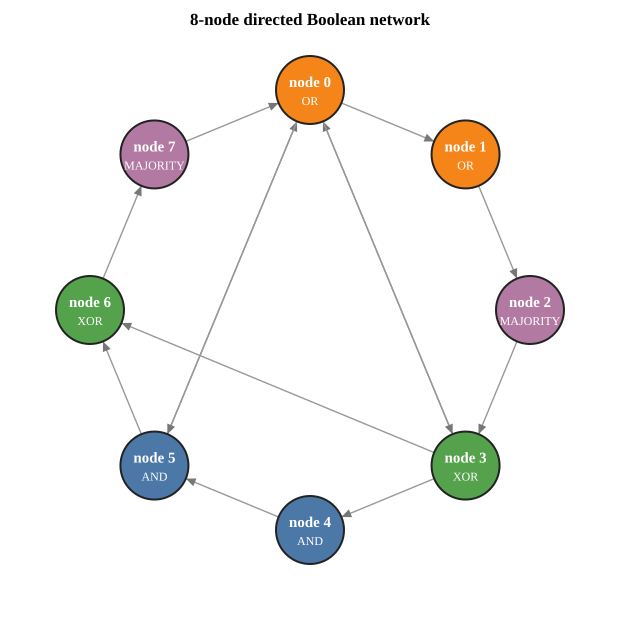

In [3]:
# Cell 3 — deterministic N=8 network
N = 8
A, gates = make_mixed_ring_network(N, seed=3)
params = [{} for _ in range(N)]
net = Network(N, A, gates, params)

def state_bits(state, n=N):
    return ''.join(str((state >> i) & 1) for i in range(n))

node_table = pd.DataFrame({
    'node': range(N),
    'inputs (sources)': [net.connected_inputs(i) for i in range(N)],
    'gate': gates,
    'in-degree': indegrees(A),
    'out-degree': outdegrees(A),
})
print(f'N={N}; full state alphabet size=2**N={1 << N}; edges={sum(map(sum, A))}')
show_table(node_table, 'Local update rules')
display(SVG(svg_network(A, gates, '8-node directed Boolean network')))

**A[target][source]**

,source 0,source 1,source 2,source 3,source 4,source 5,source 6,source 7
target 0,0,0,0,1,0,1,0,1
target 1,1,0,0,0,0,0,0,0
target 2,0,1,0,0,0,0,0,0
target 3,1,0,1,0,0,0,0,0
target 4,0,0,0,1,0,0,0,0
target 5,1,0,0,0,1,0,0,0
target 6,0,0,0,1,0,1,0,0
target 7,0,0,0,0,0,0,1,0


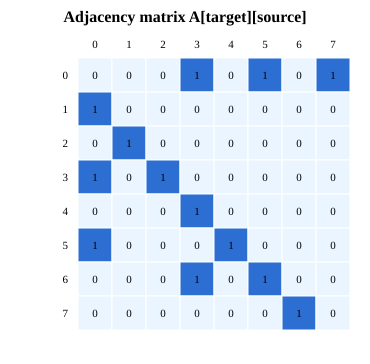

In [4]:
# Cell 4 — adjacency matrix: rows are targets, columns are sources
adjacency_frame = pd.DataFrame(A, index=[f'target {i}' for i in range(N)],
                               columns=[f'source {i}' for i in range(N)])
show_table(adjacency_frame, 'A[target][source]')
display(SVG(svg_heatmap(A, 'Adjacency matrix A[target][source]',
                       row_labels=range(N), col_labels=range(N))))

## 3. From local rules to the complete one-step map

The one-step map is the deterministic function `F(x)`. Exact enumeration evaluates it for all 256 current states. This is the immediate dynamics, not yet the long-run observable.

In [5]:
# Cell 5 — exact transition map
nxt = transition_map(net)
assert len(nxt) == 1 << N

selected_states = [0, 1, 42, 85, 127, 170, 255]
transition_examples = pd.DataFrame({
    'current decimal': selected_states,
    'current bits (node 0 first)': [state_bits(x) for x in selected_states],
    'next decimal F(x)': [nxt[x] for x in selected_states],
    'next bits': [state_bits(nxt[x]) for x in selected_states],
})
show_table(transition_examples, 'Examples from the exact one-step map')
print(f'Every one of the {1 << N} states has exactly one successor: {len(set(nxt))} distinct outputs are used.')

**Examples from the exact one-step map**

,current decimal,current bits (node 0 first),next decimal F(x),next bits
0,0,00000000,0,00000000
1,1,10000000,10,01010000
2,42,01010100,21,10101000
3,85,10101010,162,01000101
4,127,11111110,183,11101101
5,170,01010101,21,10101000
6,255,11111111,183,11101101


Every one of the 256 states has exactly one successor: 120 distinct outputs are used.


## 4. Follow trajectories until they enter cycles

There are two layers here, and your interpretation of the first layer is exactly right.

**Layer 1 — the exhaustive static input/output map.** We enumerate every possible state `x` once and calculate `F(x)`. This gives 256 input rows and 256 corresponding output rows. The order of those rows does not matter: we could process states from top to bottom, bottom to top, or randomly and still obtain the same complete map. At this layer there is no time and no cycle. If `F(42)=21` and `F(170)=21`, that simply means two different inputs have the same one-step output; it is a collision in the image of `F`.

**Layer 2 — feedback through the same map.** To study autonomous dynamics, we take an output and use it as the next input: `x_0 → F(x_0)=x_1 → F(x_1)=x_2 → ...`. Time matters only in this second layer. The next cell follows this feedback chain from initial state 42. For this example the chain is

`42 → 21 → 34 → 69 → 130 → 5 → 2 → 4 → 8 → 81 → 170 → 21`.

The final `21` is the first repeated state. Therefore `[21, 34, 69, 130, 5, 2, 4, 8, 81, 170]` is a 10-state **attractor cycle**. State 42 is **transient**: it is visited on the way in but is not revisited. A **basin** is the set of all possible initial states that eventually enter this same cycle.

In the table, `state` is the current `x_t` in decimal, `bits` is the same state as an 8-bit vector, `next` is `F(x_t)=x_(t+1)` in decimal, and `role` says whether that row is before the loop (`transient`) or inside the loop (`attractor cycle`). In the plot, columns 0–7 are nodes.

**Trajectory from state 42; cycle begins at time 1**

,time,state,bits (node 0 first),next,role
0,0,42,01010100,21,transient (leads to cycle)
1,1,21,10101000,34,attractor cycle
2,2,34,01000100,69,attractor cycle
3,3,69,10100010,130,attractor cycle
4,4,130,01000001,5,attractor cycle
5,5,5,10100000,2,attractor cycle
6,6,2,01000000,4,attractor cycle
7,7,4,00100000,8,attractor cycle
8,8,8,00010000,81,attractor cycle
9,9,81,10001010,170,attractor cycle


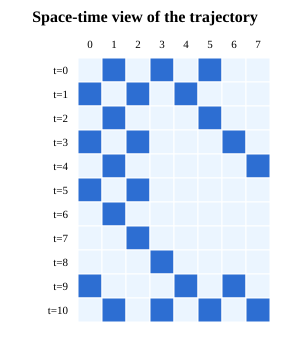

The repeated state is 21; the cycle has length 10.


In [6]:
# Cell 6 — an illustrative trajectory with cycle detection
def trajectory_until_cycle(start, successor, limit=40):
    seen = {}
    path = []
    state = start
    while state not in seen and len(path) < limit:
        seen[state] = len(path)
        path.append(state)
        state = successor[state]
    cycle_start = seen.get(state)
    return path, cycle_start, state

start_state = 42
path, cycle_start, repeated_state = trajectory_until_cycle(start_state, nxt)
trajectory_frame = pd.DataFrame({
    'time': range(len(path)),
    'state': path,
    'bits (node 0 first)': [state_bits(x) for x in path],
    'next': [nxt[x] for x in path],
    'role': ['transient (leads to cycle)' if i < cycle_start else 'attractor cycle' for i in range(len(path))],
})
show_table(trajectory_frame, f'Trajectory from state {start_state}; cycle begins at time {cycle_start}')
display(SVG(svg_heatmap([[int(bit) for bit in state_bits(x)] for x in path],
                       'Space-time view of the trajectory',
                       row_labels=[f't={i}' for i in range(len(path))],
                       col_labels=[str(i) for i in range(N)], cell=24)))
print(f'The repeated state is {repeated_state}; the cycle has length {len(path[cycle_start:])}.')

## 5. Construct the primary exact observable

This section deliberately uses several table levels. They are related, but they do not have the same row meaning:

- **Table 5.1 — cycle level:** one row per attractor cycle. `cycle states` lists every recurrent state in that cycle; `cycle length` is the number of those states; `basin size` counts all initial states that eventually enter the cycle; `basin fraction` divides that count by 256; and `phase weight per cycle state` is the mass assigned to each recurrent state after phase averaging.
- **Table 5.2 — basin-count audit:** one row per cycle, independently reconstructed by grouping the 256 initial states. Its `initial states in basin` column is expected to equal Table 5.1's `basin size`; this is a synchronization check, not a different quantity.
- **Table 5.3 — initial-state level:** one row per initial state. It shows which cycle that initial state reaches and how many updates are needed before it first enters the cycle.
- **Table 5.4 — recurrent-state probability level:** one row per distinct state that lies on an attractor. It explains the exact probability of each recurrent state.
- **Table 5.5 — ranked recurrent-state view:** a shortened display of Table 5.4, sorted by probability. It is not a list of initial states.


For every one of the 256 initial states, we follow the trajectory to its attractor. If the attractor has length `L`, that initial condition contributes `1/L` to each of its `L` cycle states. Averaging over all initial states gives

$$
p(s)=\frac{1}{2^N}\sum_{x_0}\frac{\mathbf 1\{s\in A(x_0)\}}{|A(x_0)|}.
$$

This is basin-weighted and phase-averaged. It is not a histogram of the immediate outputs `F(x)`.

### Why the phase-weight denominator changes

Every initial state has probability `1/256`. Suppose `B` initial states belong to a basin and its attractor cycle has length `L`. Each of those `B` initial states contributes `1/256` total mass, and that mass is divided equally among the `L` phases. Therefore every state on that cycle receives

$$
\text{weight per cycle state}=\frac{B}{256\,L}.
$$

The denominator is therefore `256 × L`, not a new state-space size. For a fixed point (`L=1`) it is `256`; for a 10-cycle it is `2560`; for a 5-cycle it is `1280`. The total mass of the whole cycle is still

$$
L\times\frac{B}{256L}=\frac{B}{256}.
$$

This cancellation is important: basin size determines how much probability the attractor receives, while cycle length determines how that probability is spread across its recurrent states. Without the factor `L`, long cycles would be over-counted simply because they contain more phases. The common repertoire denominator `2560` is the exact common denominator needed to represent all cycles in this example.

observable: basin_weighted_attractor_repertoire
initial states averaged: 256
attractor states in support: 36
exact common denominator: 2560


**Table 5.1 — attractors and their basins (one row per cycle)**

,attractor cycle ID,cycle states (decimal),cycle length,basin size,basin fraction,phase weight per cycle state
0,0,"(0,)",1,2,2/256,2/256
1,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,44/256,44/2560
2,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,109/256,109/2560
3,3,"(13, 29, 39, 71, 83, 115, 134, 151, 174, 239)",10,72,72/256,72/2560
4,4,"(23, 38, 77, 175, 211)",5,29,29/256,29/1280


Each row below is one attractor cycle. The bar shows the total mass of its basin. The circles are the recurrent states; every circle in the same row receives the same phase-averaged weight. Thus a longer cycle spreads the same basin mass over more states.

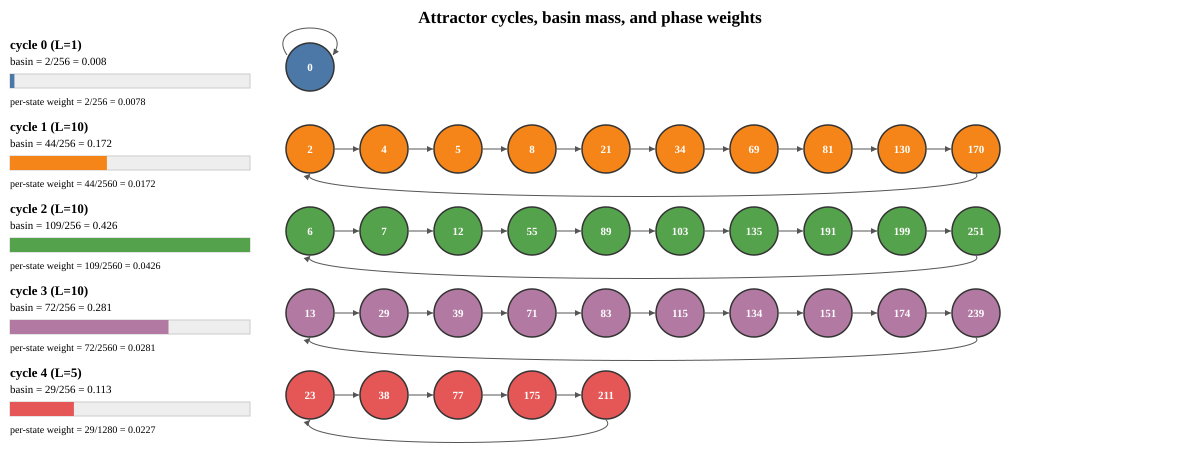

Table 5.2 is an independent audit of Table 5.1. It counts the rows in the 256-row assignment table after grouping by cycle. Therefore `initial states in basin` should exactly reproduce `basin size`; the matching values are intentional.

**Table 5.2 — basin-count audit (one row per cycle)**

,attractor cycle ID,attractor cycle (decimal),initial states in basin,cycle length,basin fraction
0,0,"(0,)",2,1,0.007812
1,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",44,10,0.171875
2,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",109,10,0.425781
3,3,"(13, 29, 39, 71, 83, 115, 134, 151, 174, 239)",72,10,0.281250
4,4,"(23, 38, 77, 175, 211)",29,5,0.113281


**Table 5.3 — first 20 rows of the 256-row initial-state assignment table**

,initial state,initial bits,attractor cycle ID,attractor cycle (decimal),cycle length,transient steps before cycle
0,0,00000000,0,"(0,)",1,0
1,1,10000000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,4
2,2,01000000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,0
3,3,11000000,3,"(13, 29, 39, 71, 83, 115, 134, 151, 174, 239)",10,4
4,4,00100000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,0
5,5,10100000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,0
6,6,01100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,0
7,7,11100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,0
8,8,00010000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,0
9,9,10010000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,4


**Table 5.4 — exact repertoire probabilities (one row per recurrent state)**

,state,bits,attractor cycle ID,attractor cycle (decimal),cycle length,basin size,exact probability,count / common denominator,decimal probability
0,0,00000000,0,"(0,)",1,2,1/128,20/2560,0.007812
1,2,01000000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,11/640,44/2560,0.017188
2,4,00100000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,11/640,44/2560,0.017188
3,5,10100000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,11/640,44/2560,0.017188
4,6,01100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,109/2560,109/2560,0.042578
5,7,11100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,109/2560,109/2560,0.042578
6,8,00010000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,11/640,44/2560,0.017188
7,12,00110000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,109/2560,109/2560,0.042578
8,13,10110000,3,"(13, 29, 39, 71, 83, 115, 134, 151, 174, 239)",10,72,9/320,72/2560,0.028125
9,21,10101000,1,"(2, 4, 5, 8, 21, 34, 69, 81, 130, 170)",10,44,11/640,44/2560,0.017188


### One complete probability calculation: cycle ID 2

Cycle 2 is `(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)`. Its basin has `B=109` initial states, and the cycle has `L=10` recurrent phases. Each initial state starts with mass `1/256`; phase averaging divides that mass equally among the 10 cycle states.

The accounting is: `109` initial states × `1/256` each = `109/256` total basin mass; then `109/256 ÷ 10 = 109/2560` for each recurrent state. The ten states together sum back to `10 × 109/2560 = 109/256`.

**Phase-weight accounting for one cycle**

,step,what is counted,number,mass or contribution
0,1,all possible initial states,256,each has 1/256
1,2,initial states entering cycle 2,109,109/256 total basin mass
2,3,recurrent states in cycle 2,10,divide each basin contribution by 10
3,4,"one particular recurrent state, e.g. state 6",1,109/(256×10) = 109/2560 = 0.042578
4,5,all 10 states of cycle 2,10,10×109/2560 = 109/256 = 0.425781


In [7]:
# Cell 7 — production exact repertoire
rep = compute_repertoire(net)
print(f'observable: {rep["observable"]}')
print(f'initial states averaged: {rep["rows"]}')
print(f'attractor states in support: {len(rep["support"])}')
print(f'exact common denominator: {rep["probability_denominator"]}')
assert sum(rep['counts']) == rep['probability_denominator']

cycle_rows = []
for cycle_id, (cycle, basin, phase) in enumerate(zip(rep['attractor_cycles'], rep['basin_sizes'], rep['phase_weights'])):
    cycle_rows.append({
        'attractor cycle ID': cycle_id,
        'cycle states (decimal)': tuple(cycle),
        'cycle length': len(cycle),
        'basin size': basin,
        'basin fraction': f'{basin}/{1 << N}',
        'phase weight per cycle state': f'{phase["numerator"]}/{phase["denominator"]}',
    })
show_table(pd.DataFrame(cycle_rows), 'Table 5.1 — attractors and their basins (one row per cycle)')
display(Markdown('Each row below is one attractor cycle. The bar shows the total mass of its basin. The circles are the recurrent states; every circle in the same row receives the same phase-averaged weight. Thus a longer cycle spreads the same basin mass over more states.'))
display(SVG(svg_basin_cycles(rep, N)))

cycle_id_by_state = {state: cycle_id for cycle_id, cycle in enumerate(rep['attractor_cycles']) for state in cycle}
basin_assignments = []
for initial_state in range(1 << N):
    current = initial_state
    transient_steps = 0
    while current not in cycle_id_by_state:
        current = nxt[current]
        transient_steps += 1
    cycle_id = cycle_id_by_state[current]
    basin_assignments.append({
        'initial state': initial_state,
        'initial bits': state_bits(initial_state),
        'attractor cycle ID': cycle_id,
        'attractor cycle (decimal)': tuple(rep['attractor_cycles'][cycle_id]),
        'cycle length': len(rep['attractor_cycles'][cycle_id]),
        'transient steps before cycle': transient_steps,
    })
basin_assignment_frame = pd.DataFrame(basin_assignments)
basin_count_frame = (basin_assignment_frame.groupby('attractor cycle ID', as_index=False)
                     .agg(**{'initial states in basin': ('initial state', 'size'),
                            'cycle length': ('cycle length', 'first')})
                     .assign(**{'attractor cycle (decimal)': lambda frame: frame['attractor cycle ID'].map(lambda cycle_id: tuple(rep['attractor_cycles'][cycle_id])),
                                'basin fraction': lambda frame: frame['initial states in basin'] / (1 << N)}))
basin_count_frame = basin_count_frame[['attractor cycle ID', 'attractor cycle (decimal)', 'initial states in basin', 'cycle length', 'basin fraction']]
display(Markdown('Table 5.2 is an independent audit of Table 5.1. It counts the rows in the 256-row assignment table after grouping by cycle. Therefore `initial states in basin` should exactly reproduce `basin size`; the matching values are intentional.'))
show_table(basin_count_frame, 'Table 5.2 — basin-count audit (one row per cycle)')
show_table(basin_assignment_frame.head(20), 'Table 5.3 — first 20 rows of the 256-row initial-state assignment table')
assert len(basin_assignment_frame) == 1 << N
assert basin_count_frame['initial states in basin'].sum() == 1 << N

cycle_info = {}
for cycle_id, (cycle, basin) in enumerate(zip(rep['attractor_cycles'], rep['basin_sizes'])):
    for state in cycle:
        cycle_info[state] = {'cycle ID': cycle_id, 'cycle length': len(cycle), 'basin size': basin}

probability_rows = []
for state, count, fraction, probability in zip(rep['support'], rep['counts'],
                                                rep['probability_fractions'], rep['probs']):
    probability_rows.append({'state': state, 'bits': state_bits(state),
                            'attractor cycle ID': cycle_info[state]['cycle ID'],
                            'attractor cycle (decimal)': tuple(rep['attractor_cycles'][cycle_info[state]['cycle ID']]),
                            'cycle length': cycle_info[state]['cycle length'],
                            'basin size': cycle_info[state]['basin size'],
                            'exact probability': f'{fraction["numerator"]}/{fraction["denominator"]}',
                            'count / common denominator': f'{count}/{rep["probability_denominator"]}',
                            'decimal probability': probability})
probability_frame = pd.DataFrame(probability_rows)
show_table(probability_frame, 'Table 5.4 — exact repertoire probabilities (one row per recurrent state)')
display(Markdown('### One complete probability calculation: cycle ID 2\n\nCycle 2 is `(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)`. Its basin has `B=109` initial states, and the cycle has `L=10` recurrent phases. Each initial state starts with mass `1/256`; phase averaging divides that mass equally among the 10 cycle states.\n\nThe accounting is: `109` initial states × `1/256` each = `109/256` total basin mass; then `109/256 ÷ 10 = 109/2560` for each recurrent state. The ten states together sum back to `10 × 109/2560 = 109/256`.'))
phase_accounting_frame = pd.DataFrame([
    {'step': 1, 'what is counted': 'all possible initial states', 'number': 256, 'mass or contribution': 'each has 1/256'},
    {'step': 2, 'what is counted': 'initial states entering cycle 2', 'number': 109, 'mass or contribution': '109/256 total basin mass'},
    {'step': 3, 'what is counted': 'recurrent states in cycle 2', 'number': 10, 'mass or contribution': 'divide each basin contribution by 10'},
    {'step': 4, 'what is counted': 'one particular recurrent state, e.g. state 6', 'number': 1, 'mass or contribution': '109/(256×10) = 109/2560 = 0.042578'},
    {'step': 5, 'what is counted': 'all 10 states of cycle 2', 'number': 10, 'mass or contribution': '10×109/2560 = 109/256 = 0.425781'},
])
show_table(phase_accounting_frame, 'Phase-weight accounting for one cycle')

`transient steps before cycle` counts applications of the map `F`, not row indexes and not a state label. For initial state 1, the trajectory begins `1 → 10 → 85 → 162 → 69`; state 69 is the first state belonging to the attractor cycle, so there are four transitions before cycle entry. An initial state already on a cycle has value 0.

Table 5.2 and Table 5.3 are connected: Table 5.2 is obtained by grouping all rows of Table 5.3 by attractor cycle. The complete assignment table has 256 rows; the displayed table is only its first 20 rows.

In Table 5.4, `state` means one recurrent state, not one initial condition. State 0 has probability `1/128` because it is a fixed-point attractor (`B=2`, `L=1`): `2/(256×1)=1/128`. For a 10-cycle with basin 109, every one of its ten recurrent states has `109/(256×10)=109/2560`.

`count / common denominator` is the exact integer numerator after expressing every probability with the shared denominator 2560. Thus `1/128` becomes `20/2560`, while `109/2560` remains `109/2560`. The final decimal column is only the decimal rendering of that exact fraction.

Each cell is one possible decimal state `s` from 0 to 255. The grid uses the low 4 bits horizontally and the high 4 bits vertically. Darker cells have larger long-run probability `p(s)`; white cells have zero long-run mass and are therefore transient rather than attractor states.

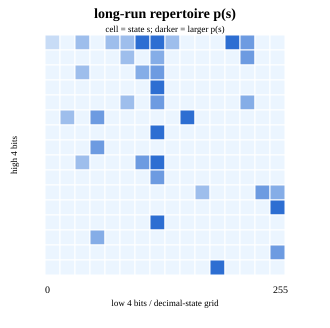

Read each row as one recurrent attractor state. The repeated basin size is intentional: all states on the same cycle share the same basin of initial conditions. The added `attractor cycle (decimal)` column makes that shared membership explicit. For example, the ten rows with cycle ID 2 each have probability `109/(256×10)`, and together they carry total mass `109/256`.

**Table 5.5 — the 12 most probable attractor states, not initial states**

attractor state (decimal),bits,cycle ID,attractor cycle (decimal),cycle length,basin size,probability
251,11011111,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
12,00110000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
135,11100001,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
55,11101100,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
103,11100110,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
191,11111101,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
89,10011010,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
199,11100011,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
7,11100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578
6,01100000,2,"(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",10,109,0.042578


In [8]:
# Cell 8 — visualize exact mass over the full 256-state alphabet
long_run_dist = dict(zip(rep['support'], rep['probs']))
display(Markdown('Each cell is one possible decimal state `s` from 0 to 255. The grid uses the low 4 bits horizontally and the high 4 bits vertically. Darker cells have larger long-run probability `p(s)`; white cells have zero long-run mass and are therefore transient rather than attractor states.'))
display(SVG(svg_distribution_grid([long_run_dist], ['long-run repertoire p(s)'], N)))

cycle_info = {}
for cycle_id, (cycle, basin) in enumerate(zip(rep['attractor_cycles'], rep['basin_sizes'])):
    for state in cycle:
        cycle_info[state] = {'cycle ID': cycle_id, 'cycle length': len(cycle), 'basin size': basin}
state_mass_frame = pd.DataFrame({
    'attractor state (decimal)': rep['support'],
    'bits': [state_bits(s) for s in rep['support']],
    'cycle ID': [cycle_info[s]['cycle ID'] for s in rep['support']],
    'attractor cycle (decimal)': [tuple(rep['attractor_cycles'][cycle_info[s]['cycle ID']]) for s in rep['support']],
    'cycle length': [cycle_info[s]['cycle length'] for s in rep['support']],
    'basin size': [cycle_info[s]['basin size'] for s in rep['support']],
    'probability': rep['probs'],
}).sort_values('probability', ascending=False)
display(Markdown('Read each row as one recurrent attractor state. The repeated basin size is intentional: all states on the same cycle share the same basin of initial conditions. The added `attractor cycle (decimal)` column makes that shared membership explicit. For example, the ten rows with cycle ID 2 each have probability `109/(256×10)`, and together they carry total mass `109/256`.'))
show_table(state_mass_frame.head(12).reset_index(drop=True).style.hide(axis='index'), 'Table 5.5 — the 12 most probable attractor states, not initial states')

## 6. Independent exact validation

### What is a trajectory oracle?

A **trajectory oracle** is a second, deliberately transparent calculation used as an independent acceptance owner. It does not reuse the production routine's cycle cache. Instead, for each initial state `x_0`, it keeps a local list of visited states and walks `x_0 → F(x_0) → F(F(x_0)) → ...` until a state repeats. The repeated suffix is the attractor cycle for that initial state.

The oracle then counts how many initial states reach each cycle and adds an exact `Fraction(1/L)` contribution to each of the `L` states in that cycle. Finally it divides by the 256 equally likely initial states. It is slower than the production implementation, but its logic is simple enough to inspect line by line.

The word **independent** refers to the algorithmic path and ownership of the calculation: production computes one cached map and reuses discovered cycles, while the oracle performs per-initial-state walks and reconstructs the result. Both must use the same declared network semantics, so this is an independent computational check—not a claim that the two programs use different scientific definitions or different gates.

### What is the final vector?

The final long-run object is the probability vector `p(s)` over the 256-state alphabet. For this example only 36 states have nonzero mass, so the record stores the sorted `support` and the corresponding `probs` list; conceptually, the other 220 coordinates are zero. For example, the coordinate for state 6 is `p(6)=0.042578...`. These decimal numbers are a convenient display of the exact rational probabilities; they are not the acceptance standard.

A floating-point vector alone could hide a serious error: two wrong calculations might round to nearly the same decimals, or have the same probabilities but assign them to the wrong state labels. We therefore compare the complete exact structure: the 256-entry transition map, the canonical cycle state sets, basin sizes, per-cycle phase-weight fractions, sorted support, exact probability fractions, and their common denominator.

### What each equality check means

- **Transition map:** for every state `x`, production and oracle must return the same successor `F(x)`. This catches gate, orientation, bit-order, and one-step errors.
- **Canonical attractor cycles:** the same recurrent state sets must be found. Canonicalization sorts the states inside each cycle, so the result does not depend on which phase was encountered first.
- **Basin sizes:** the same number of the 256 initial states must flow into each cycle. This checks the transient-to-cycle assignments.
- **Phase weights:** for a cycle with basin `B` and length `L`, both owners must report exactly `B/(256×L)` per cycle state.
- **Exact probabilities:** support, integer counts, common denominator, and rational numerator/denominator pairs must all agree—not merely their decimal approximations.
- **Support:** the same 36 states must have nonzero long-run mass.

The next cell displays these checks as a visual audit. Every green `True` is a separate equality; only after all of them pass is the exact observable accepted.

In [9]:
# Cell 9 — exact owner agreement is the acceptance gate
from doppel_challenge.oracle import independent_repertoire

oracle_rep = independent_repertoire(net)
validation = validate_repertoire(net, rep)
owner_comparison = compare_long_run_owners(net)
validation_frame = pd.DataFrame({
    'check': list(owner_comparison),
    'result': list(owner_comparison.values()),
})
show_table(validation_frame, 'Production versus independent trajectory oracle — pass/fail checks')

def exact_probability_text(record, state):
    position = record['support'].index(state)
    fraction = record['probability_fractions'][position]
    return f'{fraction["numerator"]}/{fraction["denominator"]}'

cycle_preview = tuple(rep['attractor_cycles'][2])
phase_preview = ', '.join(f'{item["numerator"]}/{item["denominator"]}' for item in rep['phase_weights'])
validation_detail_frame = pd.DataFrame([
    {'check': 'transition map', 'production evidence': f'{len(rep["transition_map"])} successors; F(42)={rep["transition_map"][42]}', 'oracle evidence': f'{len(oracle_rep["transition_map"])} successors; F(42)={oracle_rep["transition_map"][42]}', 'equal': owner_comparison['transition_map_equal']},
    {'check': 'canonical attractor cycles', 'production evidence': f'{len(rep["attractor_cycles"])} cycles; cycle 2={cycle_preview}', 'oracle evidence': f'{len(oracle_rep["attractor_cycles"])} cycles; cycle 2={tuple(oracle_rep["attractor_cycles"][2])}', 'equal': owner_comparison['attractor_cycles_equal']},
    {'check': 'basin sizes', 'production evidence': str(rep['basin_sizes']), 'oracle evidence': str(oracle_rep['basin_sizes']), 'equal': owner_comparison['basin_sizes_equal']},
    {'check': 'phase weights', 'production evidence': phase_preview, 'oracle evidence': ', '.join(f'{item["numerator"]}/{item["denominator"]}' for item in oracle_rep['phase_weights']), 'equal': owner_comparison['phase_weights_equal']},
    {'check': 'exact probability records', 'production evidence': f'{len(rep["support"])} states; p(6)={exact_probability_text(rep, 6)}; denominator={rep["probability_denominator"]}', 'oracle evidence': f'{len(oracle_rep["support"])} states; p(6)={exact_probability_text(oracle_rep, 6)}; denominator={oracle_rep["probability_denominator"]}', 'equal': owner_comparison['exact_probabilities_equal']},
    {'check': 'support', 'production evidence': f'{len(rep["support"])} states: {rep["support"][:3]} ... {rep["support"][-3:]}', 'oracle evidence': f'{len(oracle_rep["support"])} states: {oracle_rep["support"][:3]} ... {oracle_rep["support"][-3:]}', 'equal': owner_comparison['support_equal']},
])
show_table(validation_detail_frame, 'Visual audit: the two owners produce the same scientific objects')
display(Markdown('**Validation flow:** same declared network → production owner and trajectory oracle → compare exact structures → accept only if every row is `True`. A matching decimal vector alone would not test the structure behind the probabilities.'))
assert validation['valid']
assert owner_comparison['accepted']
print('ACCEPTED: the complete exact long-run observable has independent-owner agreement.')

**Production versus independent trajectory oracle — pass/fail checks**

,check,result
0,transition_map_equal,True
1,attractor_cycles_equal,True
2,basin_sizes_equal,True
3,phase_weights_equal,True
4,exact_probabilities_equal,True
5,basin_repertoire_equal,True
6,support_equal,True
7,accepted,True


**Visual audit: the two owners produce the same scientific objects**

,check,production evidence,oracle evidence,equal
0,transition map,256 successors; F(42)=21,256 successors; F(42)=21,True
1,canonical attractor cycles,"5 cycles; cycle 2=(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)","5 cycles; cycle 2=(6, 7, 12, 55, 89, 103, 135, 191, 199, 251)",True
2,basin sizes,"[2, 44, 109, 72, 29]","[2, 44, 109, 72, 29]",True
3,phase weights,"2/256, 44/2560, 109/2560, 72/2560, 29/1280","2/256, 44/2560, 109/2560, 72/2560, 29/1280",True
4,exact probability records,36 states; p(6)=109/2560; denominator=2560,36 states; p(6)=109/2560; denominator=2560,True
5,support,"36 states: [0, 2, 4] ... [211, 239, 251]","36 states: [0, 2, 4] ... [211, 239, 251]",True


**Validation flow:** same declared network → production owner and trajectory oracle → compare exact structures → accept only if every row is `True`. A matching decimal vector alone would not test the structure behind the probabilities.

ACCEPTED: the complete exact long-run observable has independent-owner agreement.


## 7. Two different views of the same dynamics

This section is about interpretation, not about making two distributions agree. The same update rule is used in both branches, but the branches count different things.

**The one-step question:** start with each of the 256 possible states, apply the network once, and count the immediate outputs. For example, if several states map to 21, all of those inputs contribute to the one-step count of 21. The order in which the 256 inputs are processed does not matter.

**The long-run question:** start with each of the 256 possible states, repeatedly apply the same update rule, find the cycle reached by each trajectory, and distribute that initial state's contribution across the states of the cycle. Transient states are not part of the final long-run support.

The one-step distribution therefore answers `Where does the network go next?` The long-run attractor repertoire answers `Which recurrent states remain after repeated updates, and how much initial-state basin mass supports them?` These are different observables and are not expected to be equal. Section 6, rather than this comparison, is the formal validation of the long-run implementation.

**The two observables use the same map but count different events**

,observable,what is counted,transient states can appear,support size,denominator,plain-language question
0,one-step output distribution,each immediate output F(x),yes,120,256,Where does the network go next?
1,long-run attractor repertoire,each attractor phase reached by an initial state,no,36,2560,Where does it remain in the long run?


**Exact schema-cover summary of all 256 states**

,category,target states,number of schemata,dont-care range,sum of schema cube sizes,exact union covered,overlap in displayed cover,assigned probability mass
0,immediate one-step outputs,120,4,5 to 6,192,120,72,1.00000
1,long-run recurrent states,36,16,0 to 2,49,36,13,1.00000
2,one-step-only transient states,84,14,2 to 4,164,84,80,0.71875
3,not reached after one step,136,3,6 to 6,192,136,56,0.00000


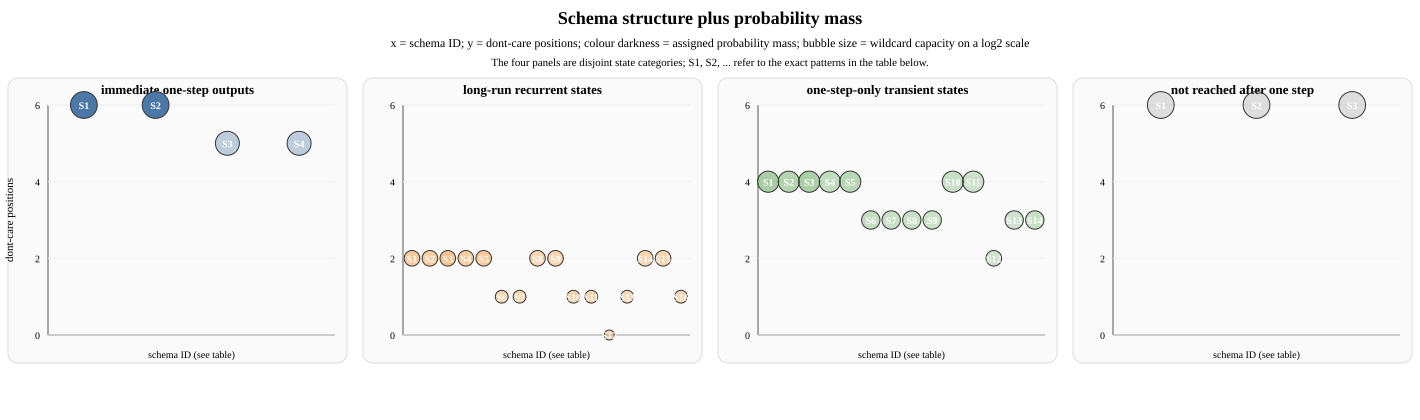

**Schema patterns and their exact wildcard capacity**

,category,schema ID,schema (node 0 first),fixed bits,dont-care positions,states in schema cube,new states covered,assigned probability mass
0,immediate one-step outputs,1,11******,2,6,64,64,0.437500
1,immediate one-step outputs,2,1****0**,2,6,64,32,0.437500
2,immediate one-step outputs,3,*1**0*0*,3,5,32,16,0.062500
3,immediate one-step outputs,4,****000*,3,5,32,8,0.062500
4,long-run recurrent states,1,01*00*00,6,2,4,4,0.099609
5,long-run recurrent states,2,00**0000,6,2,4,4,0.084766
6,long-run recurrent states,3,1110*00*,6,2,4,4,0.135937
7,long-run recurrent states,4,101*00*0,6,2,4,4,0.085156
8,long-run recurrent states,5,11100**0,6,2,4,3,0.098828
9,long-run recurrent states,6,11001*10,7,1,2,2,0.056250


**How to interpret the schema plot.** A pattern such as `11******` fixes two node bits and leaves six positions open. It therefore describes 2^6 = 64 possible states. A pattern with no `*` describes exactly one state. The schema cover describes which parts of the 256-state alphabet are immediate outputs, long-run recurrent states, transient-only states, or never reached after one update. Bubble darkness shows the probability mass assigned to the states newly covered by that schema. Because exact schema covers can overlap, the `new states covered` and `assigned probability mass` columns use an ordered non-overlapping audit partition for visualisation; the scientific distributions themselves are unchanged.

**How the 256-state alphabet is partitioned in this example**

,state category,number of states,what this means
0,recurrent attractor states,36,positive long-run mass; every cycle state has a predecessor on its cycle
1,transient but reached after one step,84,positive immediate mass but zero long-run mass
2,not reached after one step,136,zero immediate mass for this update map


**How to combine the views.** The schema plot explains the geometry of the state sets: shared fixed bits and wildcard capacity. The colour adds the corresponding probability mass. The exact state-by-state table and bar plot remain necessary because different states inside one schema can have different probabilities.

**Concrete state-by-state comparison**

,state,one-step count,one-step probability,cycle ID,basin / cycle length,long-run probability,interpretation
0,0,2,2/256 = 0.007812,0,2 / 1,1/128 = 0.007812,fixed point
1,6,1,1/256 = 0.003906,2,109 / 10,109/2560 = 0.042578,"large basin, recurrent"
2,21,4,4/256 = 0.015625,1,44 / 10,11/640 = 0.017188,recurrent cycle state
3,42,1,1/256 = 0.003906,-,not recurrent,0 = 0.000000,transient: immediate mass disappears later
4,251,2,2/256 = 0.007812,2,109 / 10,109/2560 = 0.042578,recurrent cycle state


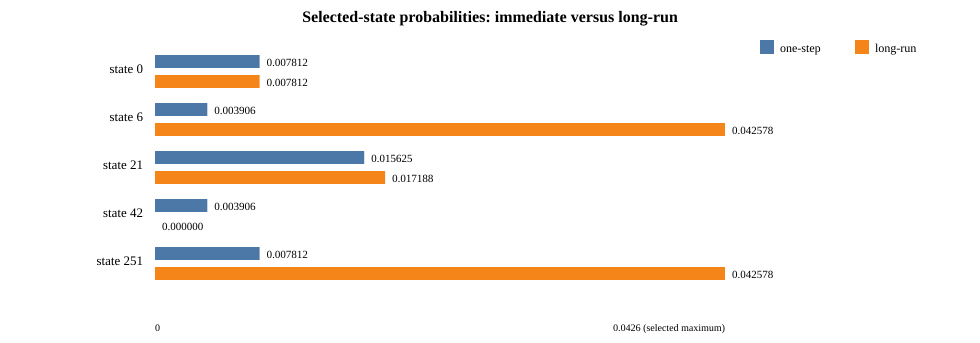

support overlap: 36 states (all recurrent states are immediate outputs of their cycles)
This is a conceptual comparison, not the formal long-run validation. Section 6 performs that validation with the independent oracle.


In [10]:
# Cell 10 — compare immediate output mass with long-run attractor mass
one_step = rep['one_step_output_distribution']
one_step_dist = dict(zip(one_step['support'], one_step['probs']))
long_run_dist = dict(zip(rep['support'], rep['probs']))
total_states = 1 << N

# This small diagram shows that both observables start from the same
# exhaustive state alphabet but apply different counting rules.
def svg_observable_branches(width=1180, height=330):
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">',
            '<defs><marker id="section7-arrow" markerWidth="9" markerHeight="7" refX="8" refY="3.5" orient="auto"><path d="M0,0 L0,7 L9,3.5 z" fill="#555"/></marker></defs>',
            f'<text x="{width/2}" y="25" text-anchor="middle" font-size="18" font-weight="bold">Same network, two questions</text>']
    boxes = [
        (30, 125, 190, 70, '#e8eef7', '256 possible states', 'each input gets one vote'),
        (285, 55, 245, 85, '#dce8f6', 'ONE STEP', 'apply F(x) once'),
        (590, 38, 260, 120, '#c9dcf2', 'one-step distribution', '120 output states; denominator 256'),
        (285, 205, 245, 85, '#fbe7d4', 'LONG RUN', 'iterate F until a cycle'),
        (590, 188, 260, 120, '#f8d5b3', 'long-run repertoire', '36 recurrent states; denominator 2560'),
    ]
    for x, y, w, h, fill, title, subtitle in boxes:
        bits.append(f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="12" fill="{fill}" stroke="#555" stroke-width="1.5"/>')
        bits.append(f'<text x="{x+w/2}" y="{y+31}" text-anchor="middle" font-size="15" font-weight="bold">{_esc(title)}</text>')
        bits.append(f'<text x="{x+w/2}" y="{y+55}" text-anchor="middle" font-size="12">{_esc(subtitle)}</text>')
    bits.append('<line x1="220" y1="160" x2="275" y2="100" stroke="#555" stroke-width="2" marker-end="url(#section7-arrow)"/>')
    bits.append('<line x1="220" y1="160" x2="275" y2="247" stroke="#555" stroke-width="2" marker-end="url(#section7-arrow)"/>')
    bits.append('<line x1="535" y1="97" x2="580" y2="97" stroke="#555" stroke-width="2" marker-end="url(#section7-arrow)"/>')
    bits.append('<line x1="535" y1="247" x2="580" y2="247" stroke="#555" stroke-width="2" marker-end="url(#section7-arrow)"/>')
    bits.append(f'<text x="930" y="105" font-size="13">immediate outputs</text>')
    bits.append(f'<text x="930" y="255" font-size="13">cycles and basins</text>')
    bits.append('</svg>')
    return ''.join(bits)

# The schema visualisation below replaces the earlier flow diagram.

comparison = pd.DataFrame({
    'observable': ['one-step output distribution', 'long-run attractor repertoire'],
    'what is counted': ['each immediate output F(x)', 'each attractor phase reached by an initial state'],
    'transient states can appear': ['yes', 'no'],
    'support size': [len(one_step['support']), len(rep['support'])],
    'denominator': [one_step['probability_denominator'], rep['probability_denominator']],
    'plain-language question': ['Where does the network go next?', 'Where does it remain in the long run?'],
})
show_table(comparison, 'The two observables use the same map but count different events')

# A schema is a pattern over the eight node bits.  A 0 or 1 fixes a bit;
# '*' is a don't-care position and can be filled with either value.
# The helper is exact: its union covers precisely the requested state set.
from doppel_challenge.adapters import minimal_dnf

def schema_pattern(clause, n=N):
    fixed = {i: 1 for i in clause['activators']}
    fixed.update({i: 0 for i in clause['inhibitors']})
    return ''.join(str(fixed[i]) if i in fixed else '*' for i in range(n))

def schema_cube(clause, n=N):
    fixed = {i: 1 for i in clause['activators']}
    fixed.update({i: 0 for i in clause['inhibitors']})
    return {state for state in range(1 << n)
            if all(((state >> bit) & 1) == value for bit, value in fixed.items())}

recurrent_states = set(rep['support'])
one_step_states = set(one_step['support'])
schema_categories = [
    ('immediate one-step outputs', one_step_states, '#4c78a8'),
    ('long-run recurrent states', recurrent_states, '#f58518'),
    ('one-step-only transient states', one_step_states - recurrent_states, '#54a24b'),
    ('not reached after one step', set(range(total_states)) - one_step_states, '#888888'),
]
schema_rows = []
schema_summary_rows = []
for category, target_states, colour in schema_categories:
    clauses = minimal_dnf([int(state in target_states) for state in range(total_states)])
    covered_union = set()
    cube_sizes = []
    wildcard_counts = []
    for schema_id, clause in enumerate(clauses, start=1):
        covered = schema_cube(clause) & target_states
        wildcard_count = N - len(clause['activators']) - len(clause['inhibitors'])
        new_states = covered - covered_union
        mass_distribution = (long_run_dist if category == 'long-run recurrent states'
                            else one_step_dist if category != 'not reached after one step'
                            else {})
        assigned_mass = sum(mass_distribution.get(state, 0.0) for state in new_states)
        covered_union |= covered
        cube_size = 2 ** wildcard_count
        cube_sizes.append(cube_size)
        wildcard_counts.append(wildcard_count)
        schema_rows.append({
            'category': category,
            'schema ID': schema_id,
            'schema (node 0 first)': schema_pattern(clause),
            'fixed bits': N - wildcard_count,
            'dont-care positions': wildcard_count,
            'states in schema cube': cube_size,
            'new states covered': len(new_states),
            'assigned probability mass': assigned_mass,
        })
    schema_summary_rows.append({
        'category': category,
        'target states': len(target_states),
        'number of schemata': len(clauses),
        'dont-care range': f'{min(wildcard_counts)} to {max(wildcard_counts)}',
        'sum of schema cube sizes': sum(cube_sizes),
        'exact union covered': len(covered_union),
        'overlap in displayed cover': sum(cube_sizes) - len(covered_union),
        'assigned probability mass': sum(row['assigned probability mass'] for row in schema_rows
                                      if row['category'] == category),
    })
schema_frame = pd.DataFrame(schema_rows)
schema_summary = pd.DataFrame(schema_summary_rows)
show_table(schema_summary, 'Exact schema-cover summary of all 256 states')

def svg_schema_plot(rows, width=1420, height=420):
    colours = {category: colour for category, _, colour in schema_categories}
    categories = [category for category, _, _ in schema_categories]
    panel_width = width / len(categories)
    plot_top, plot_bottom = 105, 335
    max_wildcards = max((row['dont-care positions'] for row in rows), default=1)
    max_mass = max((row['assigned probability mass'] for row in rows), default=1.0)
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:18px 0 28px 0;">',
            f'<text x="{width/2}" y="24" text-anchor="middle" font-size="18" font-weight="bold">Schema structure plus probability mass</text>',
            f'<text x="{width/2}" y="47" text-anchor="middle" font-size="12">x = schema ID; y = dont-care positions; colour darkness = assigned probability mass; bubble size = wildcard capacity on a log2 scale</text>',
            f'<text x="{width/2}" y="66" text-anchor="middle" font-size="11">The four panels are disjoint state categories; S1, S2, ... refer to the exact patterns in the table below.</text>']
    for panel, category in enumerate(categories):
        subset = [row for row in rows if row['category'] == category]
        x0 = panel * panel_width
        left, right = x0 + 48, x0 + panel_width - 20
        bits.append(f'<rect x="{x0+8:.1f}" y="78" width="{panel_width-16:.1f}" height="285" rx="10" fill="#fafafa" stroke="#dddddd"/>')
        bits.append(f'<text x="{x0+panel_width/2:.1f}" y="94" text-anchor="middle" font-size="13" font-weight="bold">{_esc(category)}</text>')
        bits.append(f'<line x1="{left:.1f}" y1="{plot_bottom}" x2="{right:.1f}" y2="{plot_bottom}" stroke="#555"/>')
        bits.append(f'<line x1="{left:.1f}" y1="{plot_top}" x2="{left:.1f}" y2="{plot_bottom}" stroke="#555"/>')
        for tick in range(0, max_wildcards + 1, 2):
            y = plot_bottom - tick * (plot_bottom - plot_top) / max_wildcards
            bits.append(f'<text x="{left-8:.1f}" y="{y+4:.1f}" text-anchor="end" font-size="10">{tick}</text>')
            bits.append(f'<line x1="{left:.1f}" y1="{y:.1f}" x2="{right:.1f}" y2="{y:.1f}" stroke="#eeeeee"/>')
        if panel == 0:
            bits.append(f'<text x="{left-35:.1f}" y="{(plot_top+plot_bottom)/2:.1f}" transform="rotate(-90 {left-35:.1f},{(plot_top+plot_bottom)/2:.1f})" text-anchor="middle" font-size="11">dont-care positions</text>')
        if not subset:
            continue
        spacing = (right - left) / max(1, len(subset))
        for j, row in enumerate(subset):
            x = left + spacing * (j + 0.5)
            y = plot_bottom - row['dont-care positions'] * (plot_bottom - plot_top) / max_wildcards
            radius = 5 + 1.4 * row['dont-care positions']
            opacity = 0.25 + 0.75 * row['assigned probability mass'] / max_mass
            colour = colours[category]
            bits.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="{radius:.1f}" fill="{colour}" fill-opacity="{opacity:.3f}" stroke="#333"/>')
            bits.append(f'<text x="{x:.1f}" y="{y+4:.1f}" text-anchor="middle" fill="white" font-size="10" font-weight="bold">S{row["schema ID"]}</text>')
        bits.append(f'<text x="{(left+right)/2:.1f}" y="{plot_bottom+23}" text-anchor="middle" font-size="10">schema ID (see table)</text>')
    bits.append('</svg>')
    return ''.join(bits)

display(SVG(svg_schema_plot(schema_rows)))
show_table(schema_frame, 'Schema patterns and their exact wildcard capacity')
display(Markdown('**How to interpret the schema plot.** A pattern such as `11******` fixes two node bits and leaves six positions open. It therefore describes 2^6 = 64 possible states. A pattern with no `*` describes exactly one state. The schema cover describes which parts of the 256-state alphabet are immediate outputs, long-run recurrent states, transient-only states, or never reached after one update. Bubble darkness shows the probability mass assigned to the states newly covered by that schema. Because exact schema covers can overlap, the `new states covered` and `assigned probability mass` columns use an ordered non-overlapping audit partition for visualisation; the scientific distributions themselves are unchanged.'))

recurrent_states = set(rep['support'])
one_step_states = set(one_step['support'])
support_accounting = pd.DataFrame({
    'state category': ['recurrent attractor states', 'transient but reached after one step', 'not reached after one step'],
    'number of states': [len(recurrent_states), len(one_step_states - recurrent_states), total_states - len(one_step_states)],
    'what this means': [
        'positive long-run mass; every cycle state has a predecessor on its cycle',
        'positive immediate mass but zero long-run mass',
        'zero immediate mass for this update map',
    ],
})
show_table(support_accounting, 'How the 256-state alphabet is partitioned in this example')

display(Markdown('**How to combine the views.** The schema plot explains the geometry of the state sets: shared fixed bits and wildcard capacity. The colour adds the corresponding probability mass. The exact state-by-state table and bar plot remain necessary because different states inside one schema can have different probabilities.'))

# A few states make the distinction concrete.  State 42 is a transient
# state; state 6 belongs to the large-basin cycle 2; state 21 belongs
# to cycle 1 and illustrates that the two numbers can be close by chance.
cycle_by_state = {}
for cycle_id, (cycle, basin) in enumerate(zip(rep['attractor_cycles'], rep['basin_sizes'])):
    for state in cycle:
        cycle_by_state[state] = (cycle_id, len(cycle), basin, tuple(cycle))
exact_long_run = {s: Fraction(item['numerator'], item['denominator'])
                   for s, item in zip(rep['support'], rep['probability_fractions'])}
example_states = [0, 6, 21, 42, 251]
example_rows = []
for state in example_states:
    cycle_id, cycle_length, basin_size, cycle = cycle_by_state.get(state, ('-', '-', '-', ()))
    one_count = one_step_dist.get(state, 0.0) * total_states
    long_fraction = exact_long_run.get(state, Fraction(0, 1))
    example_rows.append({
        'state': state,
        'one-step count': int(one_count),
        'one-step probability': f'{int(one_count)}/{total_states} = {one_step_dist.get(state, 0.0):.6f}',
        'cycle ID': cycle_id,
        'basin / cycle length': f'{basin_size} / {cycle_length}' if cycle_id != '-' else 'not recurrent',
        'long-run probability': str(long_fraction) + f' = {float(long_fraction):.6f}',
        'interpretation': ('large basin, recurrent' if state == 6 else
                         'transient: immediate mass disappears later' if state == 42 else
                         'fixed point' if state == 0 else 'recurrent cycle state'),
    })
state_examples = pd.DataFrame(example_rows)
show_table(state_examples, 'Concrete state-by-state comparison')

def svg_state_mass_comparison(states, one_dist, long_dist, width=980, row_height=48):
    left, top, plot_width = 155, 55, 570
    maximum = max([one_dist.get(s, 0.0) for s in states] + [long_dist.get(s, 0.0) for s in states] + [1.0])
    # Use the largest value within the selected examples, not 1.0, for a
    # readable comparison while retaining numeric labels on every bar.
    maximum = max([one_dist.get(s, 0.0) for s in states] + [long_dist.get(s, 0.0) for s in states]) or 1.0
    height = top + len(states) * row_height + 48
    bits = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" style="display:block; clear:both; margin:16px 0 28px 0;">',
            f'<text x="{width/2}" y="22" text-anchor="middle" font-size="16" font-weight="bold">Selected-state probabilities: immediate versus long-run</text>',
            '<rect x="760" y="40" width="14" height="14" fill="#4c78a8"/><text x="780" y="52" font-size="12">one-step</text>',
            '<rect x="855" y="40" width="14" height="14" fill="#f58518"/><text x="875" y="52" font-size="12">long-run</text>']
    for i, state in enumerate(states):
        y = top + i * row_height
        one_value, long_value = one_dist.get(state, 0.0), long_dist.get(state, 0.0)
        bits.append(f'<text x="{left-12}" y="{y+18}" text-anchor="end" font-size="13">state {state}</text>')
        for offset, value, colour, label in [(0, one_value, '#4c78a8', 'one'), (20, long_value, '#f58518', 'long')]:
            bar = plot_width * value / maximum
            bits.append(f'<rect x="{left}" y="{y+offset}" width="{bar:.1f}" height="13" fill="{colour}"/>')
            bits.append(f'<text x="{left+bar+7:.1f}" y="{y+offset+11}" font-size="11">{value:.6f}</text>')
    bits.append(f'<text x="{left}" y="{height-12}" font-size="10">0</text>')
    bits.append(f'<text x="{left+plot_width}" y="{height-12}" text-anchor="end" font-size="10">{maximum:.4f} (selected maximum)</text>')
    bits.append('</svg>')
    return ''.join(bits)

display(SVG(svg_state_mass_comparison(example_states, one_step_dist, long_run_dist)))
print(f'support overlap: {len(one_step_states & recurrent_states)} states (all recurrent states are immediate outputs of their cycles)')
print('This is a conceptual comparison, not the formal long-run validation. Section 6 performs that validation with the independent oracle.')

## 8. Perturbation semantics

A radius-1 addition changes exactly one zero entry of `A` to one; a radius-1 removal changes exactly one one entry to zero. We use the study policy here: no empty-input nodes, no self-loops, and maximum in-degree 3. The identity is retained as an explicit baseline record.

**Declared perturbation families**

,kind,admissible radius-1 matrices including identity,non-identity cases
0,EDGE_ADD,40,39
1,EDGE_REMOVE,10,9


**Example `EDGE_ADD` change:** `EDGE_ADD:1,2:add`

**Changed edge for EDGE_ADD**

,target,source,operation
0,1,2,add


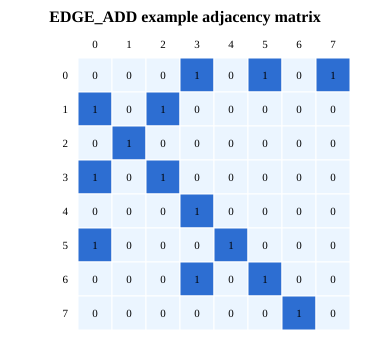

**Example `EDGE_REMOVE` change:** `EDGE_REMOVE:0,3:remove`

**Changed edge for EDGE_REMOVE**

,target,source,operation
0,0,3,remove


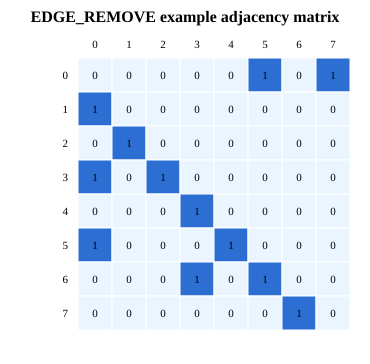

In [11]:
# Cell 11 — enumerate and inspect admissible additions/removals
policy = {
    'forbid_zero_indegree_nodes': True,
    'max_indegree': 3,
    'allow_self_loops': False,
    'gates': gates,
}
add_candidates = admissible_ball(A, 1, 'EDGE_ADD', **policy)
remove_candidates = admissible_ball(A, 1, 'EDGE_REMOVE', **policy)
perturbation_counts = pd.DataFrame({
    'kind': ['EDGE_ADD', 'EDGE_REMOVE'],
    'admissible radius-1 matrices including identity': [len(add_candidates), len(remove_candidates)],
    'non-identity cases': [len(add_candidates)-1, len(remove_candidates)-1],
})
show_table(perturbation_counts, 'Declared perturbation families')

for kind, candidates in [('EDGE_ADD', add_candidates), ('EDGE_REMOVE', remove_candidates)]:
    example = next(matrix for matrix in candidates if graph_distance(A, matrix) == 1)
    display(Markdown(f'**Example `{kind}` change:** `{perturbation_id(A, example, kind)}`'))
    show_table(pd.DataFrame(changed_edges(A, example)), f'Changed edge for {kind}')
    display(SVG(svg_heatmap(example, f'{kind} example adjacency matrix',
                           row_labels=range(N), col_labels=range(N))))

## 9. Run the durable exact catalogues

This is a compact demonstration of the production execution path. Each case gets a stable perturbation ID, an atomic checkpoint, exact validation, metrics relative to the base repertoire, and a manifest. The output directory is temporary so that executing the notebook never overwrites a scientific study.

In [12]:
# Cell 12 — exact EDGE_ADD and EDGE_REMOVE catalogues
demo_root = Path(tempfile.mkdtemp(prefix='doppel_exact_n8_'))
run_root = demo_root / 'ring_n8_s3'
target_state = rep['support'][0]  # explicit, reproducible target selection
run_kwargs = {
    'gates': gates, 'k': 1, 'seed': 3,
    'forbid_zero_indegree_nodes': True, 'max_indegree': 3,
    'allow_self_loops': False, 'loss_params': {'targets': [target_state]},
    'C': 0.25, 'resume': True, 'network_label': 'ring_n8_s3_demo',
}
summary_add = run_catalogue(A, out_dir=run_root / 'edge_add', kind='EDGE_ADD', **run_kwargs)
summary_remove = run_catalogue(A, out_dir=run_root / 'edge_remove', kind='EDGE_REMOVE', **run_kwargs)

catalogue_summary = pd.DataFrame([summary_add, summary_remove])[
    ['perturbation_kind', 'n_candidates_before_filter', 'n_admissible',
     'n_excluded', 'n_rows', 'n_accepted', 'n_failures', 'status']
]
show_table(catalogue_summary, 'Exact catalogue execution summary')
assert summary_add['n_failures'] == 0 and summary_remove['n_failures'] == 0
assert summary_add['n_accepted'] == summary_add['n_admissible']
assert summary_remove['n_accepted'] == summary_remove['n_admissible']
print('artefacts written to a temporary per-kernel demo directory')

**Exact catalogue execution summary**

,perturbation_kind,n_candidates_before_filter,n_admissible,n_excluded,n_rows,n_accepted,n_failures,status
0,EDGE_ADD,52,40,12,40,40,0,completed
1,EDGE_REMOVE,14,10,4,10,10,0,completed


artefacts written to a temporary per-kernel demo directory


In [13]:
# Cell 13 — deterministic resume: a second call adds no accepted duplicates
resume_summary = run_catalogue(A, out_dir=run_root / 'edge_add', kind='EDGE_ADD', **run_kwargs)
add_rows = read_jsonl(run_root / 'edge_add' / 'catalogue.jsonl')
latest_add = {row['perturbation_id']: row for row in add_rows}
resume_frame = pd.DataFrame([{
    'attempt records in append-only history': resume_summary['n_attempt_records'],
    'latest scientific rows': len(latest_add),
    'unique latest perturbation IDs': len(set(latest_add)),
    'accepted latest rows': sum(row.get('accepted_validation', False) for row in latest_add.values()),
}])
show_table(resume_frame, 'Resume/idempotence check')
assert len(latest_add) == resume_summary['n_admissible']
assert len(latest_add) == len(set(latest_add))
assert all(row.get('accepted_validation') for row in latest_add.values())
print('Resume is scientifically idempotent for accepted rows.')

**Resume/idempotence check**

,attempt records in append-only history,latest scientific rows,unique latest perturbation IDs,accepted latest rows
0,40,40,40,40


Resume is scientifically idempotent for accepted rows.


## 10. Compare perturbed repertoires with the base

For each accepted perturbation we compute standard forward `D_KL(p_perturbed || p_base)` over the full state alphabet. If the perturbed repertoire gives positive mass to a state absent from the base, the result is mathematically infinite; persistence uses a nullable numeric field plus an explicit status flag. Total variation, Jensen–Shannon divergence, and support distance are finite companion diagnostics.

**Descriptive effects of accepted radius-1 perturbations**

,kind,cases,infinite_KL,mean_TV,mean_JS,support_change_rate
0,EDGE_ADD,40,33,0.574005,0.344908,0.9
1,EDGE_REMOVE,10,7,0.576626,0.358419,0.8


**Largest finite total-variation changes (illustrative rows)**

,kind,perturbation,edge,D_KL (nats),KL status,TV,JS (nats),support distance,target loss
7,EDGE_ADD,"2,0:add",2,NaN,infinite,0.992188,0.684968,0.973684,0.019531
8,EDGE_ADD,"2,3:add",2,NaN,infinite,0.992188,0.684361,0.977273,0.023438
11,EDGE_ADD,"2,6:add",2,NaN,infinite,0.992188,0.684361,0.974359,0.023438
12,EDGE_ADD,"2,7:add",2,NaN,infinite,0.992188,0.671331,0.974359,0.761719
15,EDGE_ADD,"3,5:add",3,NaN,infinite,0.964063,0.647727,0.952381,0.007812
9,EDGE_ADD,"2,4:add",2,NaN,infinite,0.949609,0.636681,0.953488,0.023438
13,EDGE_ADD,"3,1:add",3,NaN,infinite,0.945312,0.644079,0.868421,0.007812
31,EDGE_ADD,"6,2:add",6,NaN,infinite,0.841553,0.565955,0.892857,0.007812
29,EDGE_ADD,"6,0:add",6,NaN,infinite,0.840088,0.566599,0.892857,0.007812
16,EDGE_ADD,"3,6:add",3,NaN,infinite,0.767578,0.468440,0.790698,0.007812


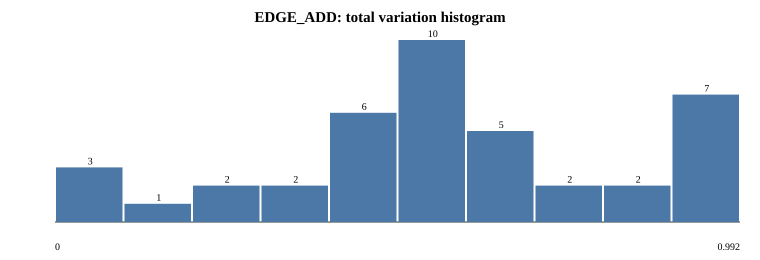

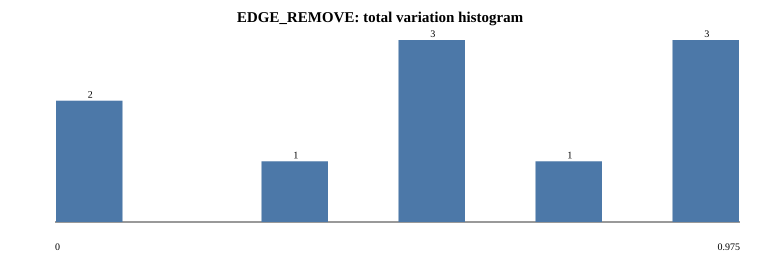

Infinite forward-KL rows: additions=33, removals=7


In [14]:
# Cell 14 — load accepted rows and make metric summaries
def accepted_rows(kind):
    path = run_root / kind.lower() / 'catalogue.jsonl'
    return [row for row in read_jsonl(path) if row.get('accepted_validation')]

add_rows = accepted_rows('EDGE_ADD')
remove_rows = accepted_rows('EDGE_REMOVE')
def metric_frame(rows, kind):
    return pd.DataFrame([{
        'kind': kind,
        'perturbation': row['perturbation_id'].replace(kind + ':', ''),
        'edge': (row.get('changed_edges') or [{'target': 'identity'}])[0].get('target', ''),
        'D_KL (nats)': row['D_KL_nats'],
        'KL status': row['divergence_status'],
        'TV': row['total_variation'],
        'JS (nats)': row['jensen_shannon'],
        'support distance': row['support']['support_jaccard'],
        'target loss': row['ell'],
    } for row in rows])

metrics = pd.concat([metric_frame(add_rows, 'EDGE_ADD'), metric_frame(remove_rows, 'EDGE_REMOVE')], ignore_index=True)
summary_metrics = metrics.groupby('kind').agg(
    cases=('kind', 'size'),
    infinite_KL=('KL status', lambda x: int((x == 'infinite').sum())),
    mean_TV=('TV', 'mean'),
    mean_JS=('JS (nats)', 'mean'),
    support_change_rate=('support distance', lambda x: float((x > 0).mean())),
).reset_index()
show_table(summary_metrics, 'Descriptive effects of accepted radius-1 perturbations')
show_table(metrics.sort_values(['kind', 'TV'], ascending=[True, False]).head(12),
           'Largest finite total-variation changes (illustrative rows)')

finite_add_tv = [row['total_variation'] for row in add_rows]
finite_remove_tv = [row['total_variation'] for row in remove_rows]
display(SVG(svg_histogram(finite_add_tv, 'EDGE_ADD: total variation histogram')))
display(SVG(svg_histogram(finite_remove_tv, 'EDGE_REMOVE: total variation histogram')))
print(f'Infinite forward-KL rows: additions={sum(row["infinite_kl"] for row in add_rows)}, removals={sum(row["infinite_kl"] for row in remove_rows)}')

In [15]:
# Cell 15 — one row worked through from first principles
worked_row = next(row for row in add_rows if not row['infinite_kl'])
worked_rep = worked_row['repertoire']
worked_p = dict(zip(worked_rep['support'], worked_rep['probs']))
base_p = dict(zip(rep['support'], rep['probs']))
manual_kl = sum(prob * math.log(prob / base_p[state])
                 for state, prob in worked_p.items() if prob > 0 and base_p.get(state, 0) > 0)
worked_metrics = {
    'perturbation_id': worked_row['perturbation_id'],
    'changed_edges': worked_row['changed_edges'],
    'stored D_KL': worked_row['D_KL_nats'],
    'manual finite-support sum': manual_kl,
    'total variation': total_variation(worked_rep, rep),
    'Jensen-Shannon': jensen_shannon(worked_rep, rep),
    'support distance': support_distance(worked_rep, rep),
}
display(pd.Series(worked_metrics))
assert math.isclose(manual_kl, worked_row['D_KL_nats'], rel_tol=1e-12, abs_tol=1e-12)
print('The stored metric agrees with a direct calculation for this finite-KL row.')

perturbation_id                                                                                                                    EDGE_ADD:identity
changed_edges                                                                                                                                     []
stored D_KL                                                                                                                                      0.0
manual finite-support sum                                                                                                                        0.0
total variation                                                                                                                                  0.0
Jensen-Shannon                                                                                                                                   0.0
support distance             {'support_jaccard': 0.0, 'support_size_A': 36, 'support_size_0': 36, 'support

The stored metric agrees with a direct calculation for this finite-KL row.


## 11. Constrained finite-catalogue optimization

The empirical frontier asks: among the enumerated perturbations satisfying `D_KL <= C`, which one maximizes the declared loss? Here the loss is the probability assigned to the prespecified baseline target state 0, and `C=0.25` nats.

This is a finite-catalogue optimum. It is not the unconstrained optimum over all possible distributions. The exponential KL-ball calculation below is a separate relaxation upper bound.

In [16]:
# Cell 16 — empirical frontiers and their relaxation bound
C = 0.25
loss_params = {'targets': [target_state]}
frontier_rows = []
for kind, rows in [('EDGE_ADD', add_rows), ('EDGE_REMOVE', remove_rows)]:
    frontier = constrained_optimum(rows, rep, C, loss_params=loss_params)
    relaxation = kl_ball_upper_bound(rep, C, 'L_SINGLE_TARGET', loss_params)
    frontier_rows.append({
        'kind': kind, 'C (nats)': C, 'target state': target_state,
        'feasible catalogue cases': frontier['n_feasible'],
        'V_k(C) empirical optimum': frontier['V_k_C'],
        'best perturbation': frontier['best_perturbation_id'],
        'best D_KL': frontier['best_D_KL_nats'],
        'KL-ball relaxation upper bound': relaxation['upper_bound'],
    })
frontier_frame = pd.DataFrame(frontier_rows)
show_table(frontier_frame, 'Finite-catalogue frontier versus unconstrained relaxation')
assert all(row['best D_KL'] is None or row['best D_KL'] <= C + 1e-12
               for row in frontier_rows)
print('Every reported empirical frontier point satisfies the declared KL budget.')

**Finite-catalogue frontier versus unconstrained relaxation**

,kind,C (nats),target state,feasible catalogue cases,V_k(C) empirical optimum,best perturbation,best D_KL,KL-ball relaxation upper bound
0,EDGE_ADD,0.25,0,3,0.015625,"EDGE_ADD:7,0:add",0.04096,0.129651
1,EDGE_REMOVE,0.25,0,1,0.003906,"EDGE_REMOVE:5,0:remove",0.01305,0.129651


Every reported empirical frontier point satisfies the declared KL budget.


## 12. A shared executable program for the whole output repertoire

The object in this section is the complete ordered one-step output matrix. Its inputs are implicit: rows 0 through 2**N-1, with LSB-first coordinates. We encode no input table. The new format, shared_repertoire_program_v1, stores one shared decision graph and N ordered output references. Repeated rules are stored once across divisions and outputs. Compilation does not enumerate inputs, full output patterns, explicit positions, or expanded Sumandos.

Each accepting decision path has an equivalent decimal anchor and free-coordinate mask. The mask generates the Sumandos by subset sums; it is not itself a list of offsets. Free coordinates include any connected coordinates that become irrelevant within that path. The program evaluates every output at the same implicit row address, preserving all correlations between columns.

For correctness: each gate is compiled by an exact Boolean identity; each decision chooses the continuation prescribed by its coordinate; merging identical continuations and removing irrelevant tests preserves that identity. An accepting path fixes an anchor and leaves all skipped coordinates free. Its generated positions therefore equal its decimal/Sumandos schema. Distinct accepting paths of one output are disjoint. The ordered output references consequently reconstruct every output bit. The tests independently check this argument against Mathematica and exhaustive matrices.

This is a new shared-program representation, not a renamed version of the previous flat column lists. The old APIs and benchmark artifacts remain available for audit. Raw length is already binary: N * 2**N. Program length includes the decision count, coordinate tests, child references, and ordered output references needed for decoding. N and the fixed decoder are shared conventions; byte padding is reported separately. A fixed-format program can exceed raw length on tiny examples. We call this our algorithmic complexity under the declared codec, not universal or minimum Kolmogorov complexity.

BDM below receives the original output matrix, with its original row/column order. It is reported separately as a model-based estimate, with version, shape, partition, and padding. Cycle, basin, transient, and phase analysis remain outside this compression object.


In [17]:
# Cell 17 — executable program, schema meaning, and complete N=8 proof
from collections import Counter
import hashlib
from doppel_challenge.repertoire_program import (
    compile_repertoire_program, compile_schema_program, evaluate_program,
    iter_output_rows, serialize_program, deserialize_program,
    export_output_schemata, program_metadata,
)
from doppel_challenge.program_benchmark import validate_program_benchmark

toy = Network(3, [[1, 1, 0]]*3, ['AND', 'OR', 'XOR'])
toy_program = compile_repertoire_program(toy)
toy_rows = list(iter_output_rows(toy_program))
show_table(pd.DataFrame({
    'implicit row (display only)': range(8),
    'output bits': [''.join(map(str, row)) for row in toy_rows],
}), 'Table 12.1 — AND / OR / XOR example: the whole output matrix')

toy_schemata = []
for output in range(3):
    for anchor, free in export_output_schemata(toy_program, output):
        offsets = [s for s in range(8) if s & ~free == 0]
        toy_schemata.append({
            'output': output, 'decimal anchor': anchor,
            'free mask (generator)': free,
            'anchor bits LSB': state_bits(anchor, 3),
            'mask bits LSB': state_bits(free, 3),
            'generated Sumandos': offsets,
            'generated one-positions': [anchor+s for s in offsets],
        })
show_table(pd.DataFrame(toy_schemata), 'Table 12.2 — Exact decimal/Sumandos interpretation')
print('Toy raw/program bits:', 24, program_metadata(toy_program)['program_bit_length'])
print('These are complete program lengths; an individual schema is only one part.')

program8 = compile_repertoire_program(net)
payload8 = serialize_program(program8)
decoded8 = deserialize_program(payload8, n=N)
metadata8 = program_metadata(program8)
output_matrix8 = list(iter_output_rows(decoded8))
expected_matrix8 = [input_vector(nxt[x], N) for x in range(1 << N)]
assert output_matrix8 == expected_matrix8

show_table(pd.DataFrame([
    {'reference': i+2, 'test coordinate': v, 'if zero': low, 'if one': high}
    for i, (v, low, high) in enumerate(program8.nodes)
]), 'N=8 shared program: terminal 0 = false, terminal 1 = true')
print('Ordered output references:', program8.outputs)
print('Program payload (hex):', payload8.hex())

# Explicit schema expansion occurs only in this small-network proof.
schema_columns = []
for output in range(N):
    positions = []
    for anchor, free in export_output_schemata(decoded8, output):
        offsets = [s for s in range(1 << N) if s & ~free == 0]
        positions.extend(anchor+s for s in offsets)
    assert len(positions) == len(set(positions))
    assert all(0 <= p < 1 << N for p in positions)
    assert sorted(positions) == [x for x, row in enumerate(expected_matrix8) if row[output]]
    schema_columns.append(set(positions))
assert [[int(x in column) for column in schema_columns] for x in range(1 << N)] == output_matrix8

selected_output = next(j for j in range(N) if any(free for _, free in export_output_schemata(decoded8, j)))
anchor8, free8 = next((a, f) for a, f in export_output_schemata(decoded8, selected_output) if f)
offsets8 = [s for s in range(1 << N) if s & ~free8 == 0]
show_table(pd.DataFrame({
    'stage': ['output column', 'decimal anchor', 'free-coordinate mask',
              'generated Sumandos', 'explicit additions', 'decoded positions'],
    'value': [selected_output, anchor8, free8, offsets8,
              [f'{anchor8} + {s}' for s in offsets8], [anchor8+s for s in offsets8]],
}), 'N=8 proof: one nontrivial schema unfolded explicitly')

# Histogram is a validation calculation, not an intermediate compiler object.
histogram8 = Counter(sum(bit << j for j, bit in enumerate(row)) for row in output_matrix8)
expected_histogram8 = Counter(nxt)
assert all(histogram8.get(pattern, 0) == expected_histogram8.get(pattern, 0)
           for pattern in range(1 << N))
assert sum(histogram8.values()) == 1 << N
assert sum((Fraction(histogram8.get(p, 0), 1 << N) for p in range(1 << N)), Fraction()) == 1
assert len(output_matrix8) == 1 << N
assert program_metadata(decoded8)['canonical_program_sha256'] == metadata8['canonical_program_sha256']
assert serialize_program(compile_repertoire_program(net, division_size=N)) == payload8
print('N=8: every output bit, every pattern count (including zero), and exact probability mass PASS.')
print('Zero-occurrence output patterns:', (1 << N)-len(histogram8))


**Table 12.1 — AND / OR / XOR example: the whole output matrix**

,implicit row (display only),output bits
0,0,000
1,1,011
2,2,011
3,3,110
4,4,000
5,5,011
6,6,011
7,7,110


**Table 12.2 — Exact decimal/Sumandos interpretation**

,output,decimal anchor,free mask (generator),anchor bits LSB,mask bits LSB,generated Sumandos,generated one-positions
0,0,3,4,110,001,"[0, 4]","[3, 7]"
1,1,2,4,010,001,"[0, 4]","[2, 6]"
2,1,1,6,100,011,"[0, 2, 4, 6]","[1, 3, 5, 7]"
3,2,2,4,010,001,"[0, 4]","[2, 6]"
4,2,1,4,100,001,"[0, 4]","[1, 5]"


Toy raw/program bits: 24 54
These are complete program lengths; an individual schema is only one part.


...

,reference,test coordinate,if zero,if one
0,2,7,0,1
1,3,5,2,1
2,4,3,3,1
3,5,0,0,1
4,6,1,0,1
5,7,2,0,1
6,8,2,1,0
7,9,0,7,8
8,10,3,0,1
9,11,4,0,1


Ordered output references: (4, 5, 6, 9, 10, 12, 15, 16)
Program payload (hex): 087042a21b100084041020a001c1604082001aa08580359cc102519251bc10


**N=8 proof: one nontrivial schema unfolded explicitly**

,stage,value
0,output column,0
1,decimal anchor,128
2,free-coordinate mask,87
3,generated Sumandos,"[0, 1, 2, 3, 4, 5, 6, 7, 16, 17, 18, 19, 20, 21, 22, 23, 64, 65, 66, 67, 68, 69, 70, 71, 80, 81, 82, 83, 84, 85, 86,..."
4,explicit additions,"[128 + 0, 128 + 1, 128 + 2, 128 + 3, 128 + 4, 128 + 5, 128 + 6, 128 + 7, 128 + 16, 128 + 17, 128 + 18, 128 + 19, 128..."
5,decoded positions,"[128, 129, 130, 131, 132, 133, 134, 135, 144, 145, 146, 147, 148, 149, 150, 151, 192, 193, 194, 195, 196, 197, 198, ..."


N=8: every output bit, every pattern count (including zero), and exact probability mass PASS.
Zero-occurrence output patterns: 136


**Table 12.3 — Exact whole-output encoding lengths**

,network,N,raw binary bits,shared program bits,stored bits (with padding),program/raw,shared decisions,compiler materializes positions,validation materializes outputs,digest
0,worked_n8,8,2048,244,248,0.119141,15,False,True,f7f4a0ead9d7
1,chapter4_n7,7,896,278,280,0.310268,18,False,True,dd21b7e84ecc
2,ring_n8_s0_base,8,2048,257,264,0.125488,16,False,True,e132aa56d3f5
3,ring_n10_s0_base,10,10240,325,328,0.031738,19,False,True,52a4c2a9c229
4,ring_n12_s0_base,12,49152,377,384,0.007670,22,False,True,ad96e03075fc
5,hub_n8_s0_base,8,2048,257,264,0.125488,16,False,True,a439b0a9212c
6,hub_n10_s0_base,10,10240,339,344,0.033105,20,False,True,775480ab8b03
7,hub_n12_s0_base,12,49152,419,424,0.008525,25,False,True,abbf48d0850e


The two materialization columns distinguish compilation from verification. Compilation builds symbolic rules; the independent small-network validation writes the output matrix to check it. The digest identifies the canonical program, N, and codec; it is not a complexity score. Larger benchmark tables are loaded here, not unfolded again.

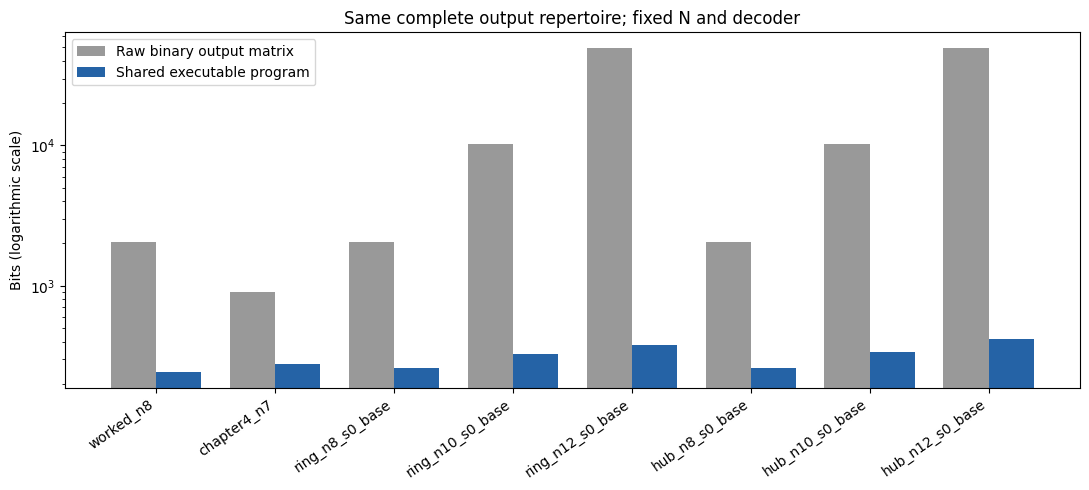

**Table 12.4 — BDM of the same original output matrices**

,network,BDM original output,status,version,original shape,padded shape,padding bits,partition / block
0,worked_n8,620.086829,completed,0.1.0,"[256, 8]","[256, 8]",0,PartitionIgnore / 4x4
1,chapter4_n7,330.382999,completed,0.1.0,"[128, 7]","[128, 8]",128,PartitionIgnore / 4x4
2,ring_n8_s0_base,516.767321,completed,0.1.0,"[256, 8]","[256, 8]",0,PartitionIgnore / 4x4
3,ring_n10_s0_base,675.948355,completed,0.1.0,"[1024, 10]","[1024, 12]",2048,PartitionIgnore / 4x4
4,ring_n12_s0_base,1101.935449,completed,0.1.0,"[4096, 12]","[4096, 12]",0,PartitionIgnore / 4x4
5,hub_n8_s0_base,736.841646,completed,0.1.0,"[256, 8]","[256, 8]",0,PartitionIgnore / 4x4
6,hub_n10_s0_base,793.807904,completed,0.1.0,"[1024, 10]","[1024, 12]",2048,PartitionIgnore / 4x4
7,hub_n12_s0_base,1309.249026,completed,0.1.0,"[4096, 12]","[4096, 12]",0,PartitionIgnore / 4x4


BDM is a model-based estimate, not the measured bit length of our program. Its input is the original matrix, never the serialized index stream. Padding is zero padding at the bottom/right edges to complete 4x4 blocks; the padding is disclosed above.

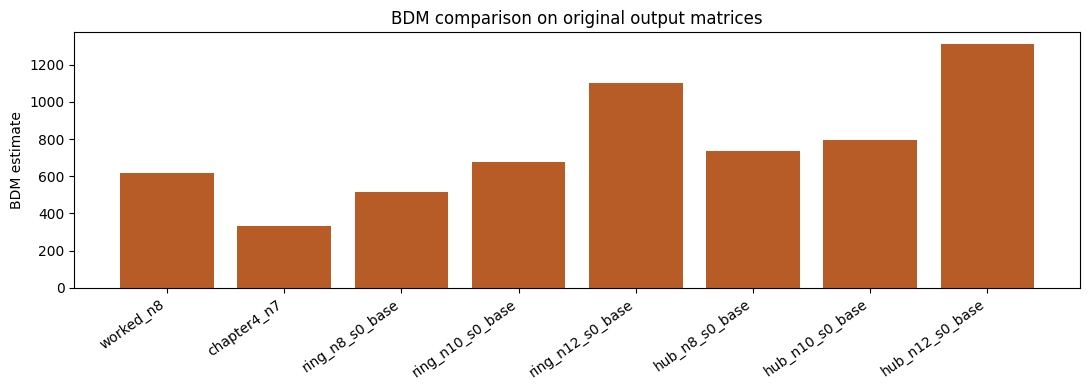

**N=100 feasibility probes: 102 checked rows, not exhaustive validation**

,network,N,program bits,shared decisions,compile seconds,validation
0,identity_n100,100,2813,100,0.000648,sampled_102_rows
1,shared_parity_n100,100,5392,199,0.003526,sampled_102_rows
2,shared_majority_n100,100,80273,2550,0.091576,sampled_102_rows


Benchmark cases: 35 ; failures: 0
Theoretical raw length N*2**N is not a claim that a large output table was produced.


In [18]:
# Cell 18 — load independently verified benchmarks; no large-table unfolding
import matplotlib.pyplot as plt

benchmark_root = repo_root / 'doppel-challenge' / 'results' / 'shared_program'
benchmark_record = json.loads((benchmark_root / 'shared_program_benchmark.json').read_text())
benchmark_check = validate_program_benchmark(benchmark_record)
assert benchmark_check['valid'], benchmark_check['errors']
assert benchmark_record['release_ready']
assert benchmark_record['n_failures'] == 0
by_label = {row['label']: row for row in benchmark_record['cases']}
worked_record = by_label['worked_n8']
assert worked_record['canonical_program_sha256'] == metadata8['canonical_program_sha256']
output_digest8 = hashlib.sha256(bytes(bit for row in output_matrix8 for bit in row)).hexdigest()
assert worked_record['wolfram_reference']['output_sha256'] == output_digest8
assert worked_record['checked_output_sha256'] == output_digest8
decoder_path = repo_root / 'doppel-challenge' / 'src' / 'doppel_challenge' / 'repertoire_program.py'
assert hashlib.sha256(decoder_path.read_bytes()).hexdigest() == benchmark_record['provenance']['decoder_source_sha256']

labels = ['worked_n8', 'chapter4_n7',
          'ring_n8_s0_base', 'ring_n10_s0_base', 'ring_n12_s0_base',
          'hub_n8_s0_base', 'hub_n10_s0_base', 'hub_n12_s0_base']
length_frame = pd.DataFrame([{
    'network': label, 'N': by_label[label]['network_size'],
    'raw binary bits': by_label[label]['raw_bit_length'],
    'shared program bits': by_label[label]['program_bit_length'],
    'stored bits (with padding)': by_label[label]['stored_bit_length'],
    'program/raw': by_label[label]['program_bit_length']/by_label[label]['raw_bit_length'],
    'shared decisions': by_label[label]['reachable_nodes'],
    'compiler materializes positions': by_label[label]['compiler_materializes_positions'],
    'validation materializes outputs': by_label[label]['validation_materializes_output_matrix'],
    'digest': by_label[label]['canonical_program_sha256'][:12],
} for label in labels])
show_table(length_frame, 'Table 12.3 — Exact whole-output encoding lengths')

display(Markdown('The two materialization columns distinguish compilation from verification. '
    'Compilation builds symbolic rules; the independent small-network validation writes the '
    'output matrix to check it. The digest identifies the canonical program, N, and codec; '
    'it is not a complexity score. Larger benchmark tables are loaded here, not unfolded again.'))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(length_frame))
ax.bar(x-.19, length_frame['raw binary bits'], .38, label='Raw binary output matrix', color='#999999')
ax.bar(x+.19, length_frame['shared program bits'], .38, label='Shared executable program', color='#2563a6')
ax.set_yscale('log')
ax.set_ylabel('Bits (logarithmic scale)')
ax.set_xticks(x, labels, rotation=35, ha='right')
ax.legend()
ax.set_title('Same complete output repertoire; fixed N and decoder')
fig.tight_layout()
figure_root = benchmark_root / 'figures'
figure_root.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_root / 'raw_vs_shared_program.svg')
fig.savefig(figure_root / 'raw_vs_shared_program.png', dpi=180)
plt.show()
plt.close(fig)

bdm_frame = pd.DataFrame([{
    'network': label, 'BDM original output': by_label[label]['bdm_original_output']['value'],
    'status': by_label[label]['bdm_original_output']['status'],
    'version': by_label[label]['bdm_original_output']['provenance']['version'],
    'original shape': by_label[label]['bdm_original_output']['provenance']['original_shape'],
    'padded shape': by_label[label]['bdm_original_output']['provenance']['padded_shape'],
    'padding bits': by_label[label]['bdm_original_output']['provenance']['padding_bits'],
    'partition / block': 'PartitionIgnore / 4x4',
} for label in labels])
show_table(bdm_frame, 'Table 12.4 — BDM of the same original output matrices')
display(Markdown('BDM is a model-based estimate, not the measured bit length of our program. '
    'Its input is the original matrix, never the serialized index stream. Padding is zero '
    'padding at the bottom/right edges to complete 4x4 blocks; the padding is disclosed above.'))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels, bdm_frame['BDM original output'], color='#b75c26')
ax.set_ylabel('BDM estimate')
ax.set_title('BDM comparison on original output matrices')
ax.tick_params(axis='x', labelrotation=35)
plt.setp(ax.get_xticklabels(), ha='right')
fig.tight_layout()
fig.savefig(figure_root / 'bdm_original_outputs.svg')
plt.show()
plt.close(fig)

large_frame = pd.DataFrame([{
    'network': row['label'], 'N': row['network_size'],
    'program bits': row['program_bit_length'], 'shared decisions': row['reachable_nodes'],
    'compile seconds': row['compile_seconds'], 'validation': row['validation_scope'],
} for row in benchmark_record['cases'] if row['network_size'] == 100])
show_table(large_frame, 'N=100 feasibility probes: 102 checked rows, not exhaustive validation')
print('Benchmark cases:', benchmark_record['n_cases'], '; failures:', benchmark_record['n_failures'])
print('Theoretical raw length N*2**N is not a claim that a large output table was produced.')


## 13. Exact versus approximate computation

At `N=8`, exact enumeration is easy. We nevertheless run the restart estimator to make the contract visible. It samples initial states and records uncertainty and convergence diagnostics; it must not be labelled exact merely because it happens to agree closely in this small example.

In [19]:
# Cell 19 — explicitly approximate restart estimator
approx = estimate_repertoire(net, samples=128, max_steps=1000, seed=123)
approx_p = dict(zip(approx['support'], approx['probs']))
approx_compare = pd.DataFrame({
    'field': ['approximation label', 'accepted_validation', 'requested restarts',
              'truncated samples', 'observed cycles', 'approximate support size'],
    'value': [approx['approximation'], approx['accepted_validation'],
              approx['estimator_parameters']['samples'],
              approx['convergence']['truncated_samples'],
              approx['convergence']['observed_cycle_count'], len(approx['support'])],
})
show_table(approx_compare, 'Approximate estimator record')
print('Exact/approximate distinction is preserved even when the sample looks stable.')
assert approx['approximation'] != 'none_exact_full_state_space'
assert approx['accepted_validation'] is False

**Approximate estimator record**

,field,value
0,approximation label,restart_trajectory_sampling
1,accepted_validation,False
2,requested restarts,128
3,truncated samples,0
4,observed cycles,5
5,approximate support size,36


Exact/approximate distinction is preserved even when the sample looks stable.


## 14. Manifest, provenance, and dependency status

The catalogue manifest validates the latest scientific row for every stable perturbation ID. Section 12 additionally validates the stored shared-program benchmark and its independent Wolfram checks. BDM is an explicit comparison using pybdm 0.1.0; it does not participate in the compiler or decoder. Its dependency status and padding are part of the saved comparison record.


In [ ]:
# Cell 20 — release-style checks for the notebook artefacts
manifest_checks = []
for kind in ('edge_add', 'edge_remove'):
    kind_root = run_root / kind
    rows = list({row['perturbation_id']: row for row in read_jsonl(kind_root / 'catalogue.jsonl')}.values())
    manifest = read_json(kind_root / 'manifest.json')
    check = validate_catalogue_manifest(manifest, rows)
    manifest_checks.append({'catalogue': kind, 'valid': check['valid'],
                           'latest rows': check['n_rows'], 'accepted': check['n_accepted'],
                           'errors': check['errors']})

release = run_release_gate(demo_root)
try:
    import pybdm  # noqa: F401
    pybdm_status = 'available (used for original-output BDM in Section 12)'
except ImportError:top
asdfasdatopasd
    pybdm_status = 'missing (Section 12 BDM release check must fail)'

show_table(pd.DataFrame(manifest_checks), 'Per-catalogue manifest validation')
show_table(pd.DataFrame([{
    'release gate status': release['status'],
    'catalogues checked': len(release['runs']),
    'release errors': len(release['errors']),
    'pybdm status': pybdm_status,
}]), 'Release boundary')
assert all(item['valid'] for item in manifest_checks)
assert release['status'] == 'passed'
print('All exact notebook artefacts pass their manifest and release checks.')

**Per-catalogue manifest validation**

,catalogue,valid,latest rows,accepted,errors
0,edge_add,True,40,40,[]
1,edge_remove,True,10,10,[]


**Release boundary**

,release gate status,catalogues checked,release errors,pybdm status
0,passed,2,0,available (used for original-output BDM in Section 12)


All exact notebook artefacts pass their manifest and release checks.


## 15. What this establishes—and what it does not

For this `N=8` example we have now seen the complete exact chain:

1. local gates and directed adjacency define a synchronous Boolean map;
2. all 256 transitions are enumerated;
3. trajectories are decomposed into cycles and basins;
4. the exact basin-weighted repertoire is built from rational probabilities;
5. an independent oracle validates the long-run observable;
6. additions and removals are enumerated under declared rules;
7. exact perturbation rows receive KL, support, TV, JS, loss, and codec diagnostics;
8. constrained empirical frontiers are separated from KL-ball relaxation bounds;
9. a serialized shared program reconstructs the entire ordered output matrix;
10. raw/program lengths and original-output BDM are reported with distinct semantics.

This supports the first paper’s narrow exact-methodology scope. It does not establish universal Kolmogorov complexity, detector performance, or unrestricted large-`N` scaling; the N=10/N=12 benchmark cases have exhaustive independent verification, while the N=100 probes have explicitly sampled validation.

In [21]:
# Cell 21 — final notebook acceptance checklist
checklist = pd.DataFrame({
    'contract item': [
        'A[target][source] orientation',
        'basin-weighted phase-averaged observable',
        'independent long-run owner agreement',
        'exact rational probability mass',
        'exact catalogue rows accepted',
        'manifest/release validation',
        'approximate results labelled approximate',
        'original-output BDM dependency and comparison',
    ],
    'status': [
        'PASS', 'PASS', 'PASS', 'PASS',
        f'PASS ({summary_add["n_accepted"] + summary_remove["n_accepted"]} rows)',
        'PASS', 'PASS', 'PASS (Section 12)',
    ],
})
show_table(checklist, 'Notebook readiness checklist')
print('END: exact N=8 walkthrough completed successfully.')

**Notebook readiness checklist**

,contract item,status
0,A[target][source] orientation,PASS
1,basin-weighted phase-averaged observable,PASS
2,independent long-run owner agreement,PASS
3,exact rational probability mass,PASS
4,exact catalogue rows accepted,PASS (50 rows)
5,manifest/release validation,PASS
6,approximate results labelled approximate,PASS
7,original-output BDM dependency and comparison,PASS (Section 12)


END: exact N=8 walkthrough completed successfully.
